# ME623: Dynamics of Machining Processes
## Chatter Detection in Turning Operations using Supervised Machine Learning

**Group 7 — Raghav Kapoor (230103081), Saket Mehla (230103087)**

---

### Project overview

This notebook builds a data-driven pipeline to detect chatter — a self-excited vibration between the cutting tool and workpiece — from cutting-force signals recorded during single-point turning. A 3-component piezoelectric dynamometer records **feed force (Fx)**, **radial force (Fy)** and **cutting/tangential force (Fz)** at 10 kHz, across 18 cuts spanning three spindle speeds (250 / 325 / 420 RPM) and depths of cut (DOC) from 100 to 1400 \u00b5m.

The pipeline has five stages:

1. **Automatic, per-file engagement detection.** Every raw recording includes a no-load period before the tool engages the workpiece and after it disengages — idle duration varies from ~9 s to ~25 s across files, so a fixed skip value would not generalize across the dataset. A detector isolates the genuine, steady-state cutting segment of each file (also guarding against a piezoelectric charge-drift artifact found in the heaviest cut), and every downstream step — features, labels, models — is restricted to that segment.
2. **Feature extraction** over 1-second sliding windows (50% overlap), combining time-domain, frequency-domain, and literature-motivated dimensionless condition-monitoring features.
3. **Labeling** via a data-driven amplitude-percentile threshold on the radial-force FFT peak. An ablation study later in the notebook quantifies exactly how much including idle-time data would inflate the reported metrics, to justify the engagement-detection step above.
4. **Modeling** — Random Forest, XGBoost and an ensemble, benchmarked with file-grouped cross-validation, then improved using a short literature review that motivates class-balanced classifiers and a leaner feature set.
5. **A stability diagram** mapping predicted chatter probability across depth-of-cut and spindle speed, for process planning.


In [1]:
# ============================================================
# 0. Imports
# ============================================================
import os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score, fbeta_score,
                              confusion_matrix, classification_report, accuracy_score)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")


Libraries loaded.


In [2]:
# ============================================================
# 1. Data discovery
# ============================================================
# Works both locally and on Google Colab. If running on Colab, mount Drive and
# point DATA_DIR at the folder containing the 250RPM / 325RPM / 420RPM subfolders.

try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/ME623_data'   # <-- adjust to your Drive path
except ImportError:
    DATA_DIR = '.'   # local: 250RPM/, 325RPM/, 420RPM/ subfolders alongside this notebook

files = sorted(glob.glob(f'{DATA_DIR}/*RPM/T1_*.csv'))
print(f"Found {len(files)} T1 files.")
files


Found 18 T1 files.


['./250RPM/T1_1000doc_250RPM_02-02-2024.csv',
 './250RPM/T1_200doc_250RPM_02-02-2024.csv',
 './250RPM/T1_400doc_250RPM_02-02-2024.csv',
 './250RPM/T1_600doc_250RPM_02-02-2024.csv',
 './250RPM/T1_800doc_250RPM_02-02-2024.csv',
 './325RPM/T1_200doc_325RPM_22-01-2024.csv',
 './325RPM/T1_400doc_325RPM_22-01-2024.csv',
 './325RPM/T1_600doc_325RPM_22-01-2024.csv',
 './325RPM/T1_700doc_325RPM_22-01-2024.csv',
 './325RPM/T1_800doc_325RPM_22-01-2024.csv',
 './420RPM/T1_100doc_420RPM_20-01-2024.csv',
 './420RPM/T1_1200doc_420RPM_20-01-2024.csv',
 './420RPM/T1_1400doc_420RPM_20-01-2024.csv',
 './420RPM/T1_200doc_420RPM_20-01-2024.csv',
 './420RPM/T1_600doc_420RPM_20-01-2024.csv',
 './420RPM/T1_700doc_420RPM_21-01-2024.csv',
 './420RPM/T1_800doc_420RPM_21-01-2024.csv',
 './420RPM/T1_900doc_420RPM_21-01-2024.csv']

In [3]:
# ============================================================
# 2. Metadata parsing
# ============================================================
meta = []
for file in files:
    name = os.path.basename(file)
    parts = name.split('_')
    tool = parts[0]                        # 'T1'
    doc  = float(parts[1].replace('doc',''))
    rpm  = int(parts[2].replace('RPM',''))
    date = parts[3].replace('.csv','')
    meta.append([name, tool, doc, rpm, date])

table1 = pd.DataFrame(meta, columns=["Filename","Tool","DOC (um)","RPM","Date"])
table1


,Filename,Tool,DOC (um),RPM,Date
0,T1_1000doc_250RPM_02-02-2024.csv,T1,1000.0,250,02-02-2024
1,T1_200doc_250RPM_02-02-2024.csv,T1,200.0,250,02-02-2024
2,T1_400doc_250RPM_02-02-2024.csv,T1,400.0,250,02-02-2024
3,T1_600doc_250RPM_02-02-2024.csv,T1,600.0,250,02-02-2024
4,T1_800doc_250RPM_02-02-2024.csv,T1,800.0,250,02-02-2024
5,T1_200doc_325RPM_22-01-2024.csv,T1,200.0,325,22-01-2024
6,T1_400doc_325RPM_22-01-2024.csv,T1,400.0,325,22-01-2024
7,T1_600doc_325RPM_22-01-2024.csv,T1,600.0,325,22-01-2024
8,T1_700doc_325RPM_22-01-2024.csv,T1,700.0,325,22-01-2024
9,T1_800doc_325RPM_22-01-2024.csv,T1,800.0,325,22-01-2024


In [4]:
# ============================================================
# 3. Basic data audit (rows, missing values, duplicates)
# ============================================================
audit = []
for file in files:
    df = pd.read_csv(file)
    audit.append({
        'file'       : os.path.basename(file),
        'rows'       : df.shape[0],
        'cols'       : df.shape[1],
        'missing'    : df.isna().sum().sum(),
        'duplicates' : df.duplicated().sum(),
        'duration_s' : df.shape[0] / 10000
    })
audit_df = pd.DataFrame(audit)
audit_df


,file,rows,cols,missing,duplicates,duration_s
0,T1_1000doc_250RPM_02-02-2024.csv,565760,3,0,362107,56.5760
1,T1_200doc_250RPM_02-02-2024.csv,550912,3,0,548343,55.0912
2,T1_400doc_250RPM_02-02-2024.csv,626585,3,0,620140,62.6585
3,T1_600doc_250RPM_02-02-2024.csv,733388,3,0,516454,73.3388
4,T1_800doc_250RPM_02-02-2024.csv,626892,3,0,391817,62.6892
5,T1_200doc_325RPM_22-01-2024.csv,367513,3,0,365774,36.7513
6,T1_400doc_325RPM_22-01-2024.csv,393523,3,0,389892,39.3523
7,T1_600doc_325RPM_22-01-2024.csv,311398,3,0,291553,31.1398
8,T1_700doc_325RPM_22-01-2024.csv,390963,3,0,308339,39.0963
9,T1_800doc_325RPM_22-01-2024.csv,398233,3,0,230242,39.8233


## 4. Why idle-time segments must be excluded

Every raw file records the dynamometer signal from *before* the tool touches the workpiece to *after* it retracts. Below is the full-duration cutting force (Fz) for one file. The flat, low-amplitude region on the left (and a similar region on the right) is the tool sitting off the workpiece while the spindle spins — no cutting is happening, so any "chatter" or "stability" statistic computed there would be meaningless. A sliding-window feature-extraction loop that simply runs across the entire file would sweep straight through this idle region and treat it as real machining data — so the first step in this pipeline is to detect and exclude it.


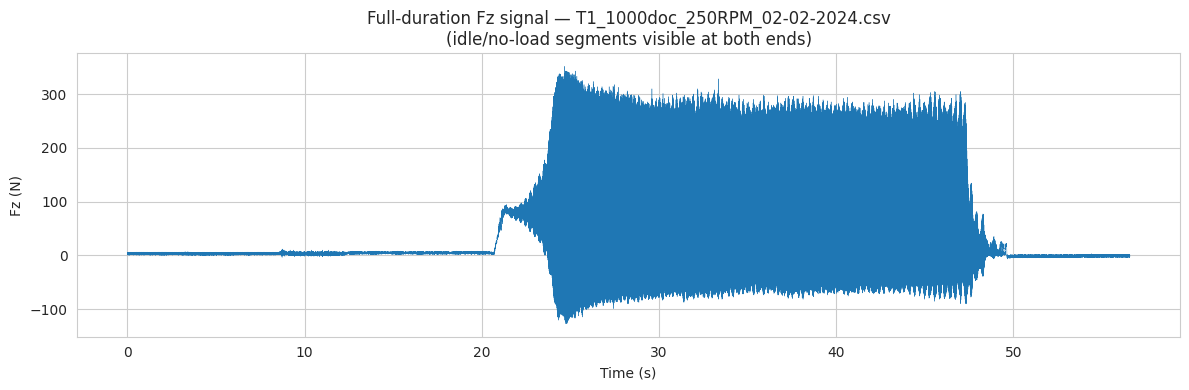

File duration: 56.6 s
Idle-region Fz mean/std (first 5 s): 3.1 / 1.08


In [5]:
# ============================================================
# 4. Visual demonstration of the issue on one file
# ============================================================
FS = 10000  # sampling frequency (Hz), inferred from the 10,000-sample 1-second plots
demo_file = [f for f in files if 'T1_1000doc_250RPM' in f][0]
demo_df = pd.read_csv(demo_file)
demo_df.columns = ['Fx','Fy','Fz']
t = np.arange(len(demo_df)) / FS

plt.figure(figsize=(12,4))
plt.plot(t, demo_df['Fz'], linewidth=0.3)
plt.title(f'Full-duration Fz signal — {os.path.basename(demo_file)}\n(idle/no-load segments visible at both ends)')
plt.xlabel('Time (s)'); plt.ylabel('Fz (N)')
plt.tight_layout()
plt.show()

print(f"File duration: {len(demo_df)/FS:.1f} s")
print("Idle-region Fz mean/std (first 5 s):",
      demo_df['Fz'].iloc[:5*FS].mean().round(2), '/', demo_df['Fz'].iloc[:5*FS].std().round(2))


## 5. Automatic engagement-window detection

A fixed "skip the first N seconds" rule does not work here: the idle duration before engagement ranges from **~9 s to ~25 s** across the 18 files (it depends on the programmed approach distance/feed, which was not held constant). Instead, each file is scanned automatically:

1. Compute the resultant force magnitude in 0.5 s windows -> RMS per window.
2. Estimate a per-file **idle baseline** from the RMS of the first 2 seconds (before any cutting could plausibly have started).
3. Flag a window as "engaged" once the RMS exceeds `baseline x 5 + 5 N` and **stays above that threshold for at least 1 continuous second** (the hold requirement rejects short transients/spikes). Scan forward for the onset and backward for the (magnitude-based) disengagement point.
4. Pull the detected boundaries in by a small 0.5 s guard band on each side, so the ramp-up/ramp-down transition itself (not steady-state cutting either) is excluded too.

**A second, independent check is needed at the tail end.** Piezoelectric dynamometers are charge-based and can exhibit slow **charge drift** after a large force transient: the reading settles at a shifted, non-zero baseline instead of returning to true zero, without any further real force being applied. A magnitude-only detector cannot tell this apart from genuine (if very heavy) cutting, because both look like "elevated force". This is addressed by also tracking the **AC/fluctuation component** (per-window standard deviation of each axis, which removes any constant offset): if a file's fluctuation was clearly high at some point during engagement (i.e. it really was cutting/vibrating, not just idle) and then **collapses back down to near-idle fluctuation levels while the magnitude stays elevated**, that is the signature of drift, not cutting, and the window is trimmed there. Files that are smooth and low-vibration for their *entire* engaged duration (some of the lighter cuts genuinely never fluctuate much -- that is a real, stable-cutting characteristic, not drift) are deliberately left alone by this check, since there is no "collapse" event to find.

If no sustained engagement is ever detected, the file is flagged rather than silently kept or dropped.


In [6]:
# ============================================================
# 5. Engagement-window detector (magnitude onset/offset + AC drift guard)
# ============================================================
WIN_SEC        = 0.5
WIN            = int(WIN_SEC * FS)
BASELINE_SEC   = 2.0
K_FACTOR       = 5.0
MARGIN_N       = 5.0
MIN_HOLD_SEC   = 1.0
EDGE_GUARD_SEC = 0.5
AC_HIGH_MULT   = 8.0
AC_QUIET_MULT  = 3.0

def detect_engagement(df):
    fx, fy, fz = df['Fx'].values, df['Fy'].values, df['Fz'].values
    mag = np.sqrt(fx**2 + fy**2 + fz**2)
    n = len(mag)
    nwin = n // WIN

    rms_mag = np.array([np.sqrt(np.mean(mag[i*WIN:(i+1)*WIN]**2)) for i in range(nwin)])
    ac = np.array([
        np.sqrt(np.std(fx[i*WIN:(i+1)*WIN])**2 + np.std(fy[i*WIN:(i+1)*WIN])**2 + np.std(fz[i*WIN:(i+1)*WIN])**2)
        for i in range(nwin)
    ])

    base_n   = max(1, int(BASELINE_SEC / WIN_SEC))
    base_mag = float(np.median(rms_mag[:base_n]))
    thresh   = base_mag * K_FACTOR + MARGIN_N
    base_ac  = float(np.median(ac[:base_n]))
    hold     = max(1, int(MIN_HOLD_SEC / WIN_SEC))

    start_idx = next((i for i in range(base_n, nwin-hold)
                       if np.all(rms_mag[i:i+hold] > thresh)), None)
    end_idx_mag = next((i for i in range(nwin-1, base_n+hold, -1)
                         if np.all(rms_mag[i-hold+1:i+1] > thresh)), None)

    engaged = start_idx is not None and end_idx_mag is not None and end_idx_mag > start_idx
    end_idx = end_idx_mag
    drift_trimmed = False

    if engaged:
        seg_ac = ac[start_idx:end_idx_mag+1]
        ever_oscillating = seg_ac.max() > base_ac * AC_HIGH_MULT
        if ever_oscillating:
            quiet_thr = base_ac * AC_QUIET_MULT
            candidate = next((i for i in range(start_idx, end_idx_mag+1)
                               if np.all(ac[i:end_idx_mag+1] < quiet_thr)), None)
            if candidate is not None and (end_idx_mag - candidate) >= hold:
                end_idx = candidate - 1
                drift_trimmed = True

    if engaged:
        start_sample, end_sample = start_idx*WIN, (end_idx+1)*WIN
        guard = int(EDGE_GUARD_SEC * FS)
        if end_sample - start_sample > 4*guard:
            start_sample += guard
            end_sample   -= guard
    else:
        start_sample, end_sample = int(2.0*FS), n

    return {
        'engaged': engaged, 'drift_trimmed': drift_trimmed,
        'baseline_rms': base_mag, 'threshold': thresh,
        'start_sample': int(start_sample), 'end_sample': int(end_sample),
        'total_sec': n/FS, 'start_sec': start_sample/FS, 'end_sec': end_sample/FS,
        'engaged_sec': (end_sample-start_sample)/FS
    }

print("detect_engagement() defined.")


detect_engagement() defined.


In [7]:
# ============================================================
# 6. Run detection on every file -> audit table
# ============================================================
data_dict = {}
engagement_rows = []

for file in files:
    df = pd.read_csv(file)
    df = df.iloc[:, 0:3]
    df.columns = ['Fx','Fy','Fz']
    df = df.apply(pd.to_numeric, errors='coerce')
    data_dict[file] = df

    name = os.path.basename(file)
    row_meta = table1[table1['Filename'] == name]
    info = detect_engagement(df)
    info.update({'file': name, 'doc': row_meta['DOC (um)'].values[0], 'rpm': row_meta['RPM'].values[0]})
    engagement_rows.append(info)

engagement_df = pd.DataFrame(engagement_rows)
excluded_files = engagement_df.loc[~engagement_df['engaged'], 'file'].tolist()

cols_show = ['file','doc','rpm','total_sec','start_sec','end_sec','engaged_sec','engaged','drift_trimmed']
engagement_df[cols_show]


,file,doc,rpm,total_sec,start_sec,end_sec,engaged_sec,engaged,drift_trimmed
0,T1_1000doc_250RPM_02-02-2024.csv,1000.0,250,56.5760,21.0,48.0000,27.0000,True,False
1,T1_200doc_250RPM_02-02-2024.csv,200.0,250,55.0912,13.5,44.5000,31.0000,True,False
2,T1_400doc_250RPM_02-02-2024.csv,400.0,250,62.6585,17.0,53.5000,36.5000,True,False
3,T1_600doc_250RPM_02-02-2024.csv,600.0,250,73.3388,25.5,63.5000,38.0000,True,False
4,T1_800doc_250RPM_02-02-2024.csv,800.0,250,62.6892,18.0,55.5000,37.5000,True,False
5,T1_200doc_325RPM_22-01-2024.csv,200.0,325,36.7513,14.0,27.0000,13.0000,True,False
6,T1_400doc_325RPM_22-01-2024.csv,400.0,325,39.3523,12.5,27.0000,14.5000,True,False
7,T1_600doc_325RPM_22-01-2024.csv,600.0,325,31.1398,9.0,21.0000,12.0000,True,False
8,T1_700doc_325RPM_22-01-2024.csv,700.0,325,39.0963,15.5,28.0000,12.5000,True,False
9,T1_800doc_325RPM_22-01-2024.csv,800.0,325,39.8233,11.5,31.5000,20.0000,True,False


In [8]:
print("Files with NO detectable engagement (excluded from modeling):", excluded_files)
print(f"\n{engagement_df['engaged'].sum()} / {len(engagement_df)} files retained.")
drift_files = engagement_df.loc[engagement_df['drift_trimmed'], 'file'].tolist()
print("Files where a trailing charge-drift artifact was detected and trimmed:", drift_files)


Files with NO detectable engagement (excluded from modeling): ['T1_100doc_420RPM_20-01-2024.csv']

17 / 18 files retained.
Files where a trailing charge-drift artifact was detected and trimmed: ['T1_1400doc_420RPM_20-01-2024.csv']


**Excluded file — `T1_100doc_420RPM_20-01-2024.csv`.** At a depth of cut of only 100 um, the resultant force never rises meaningfully above the idle noise floor for the *entire* recording (RMS stays ~1.5 N throughout, vs. hundreds of N in every other file). Physically, this is consistent with cutting below the effective minimum chip thickness for this tool/workpiece pair (rubbing/ploughing rather than clean shearing) -- i.e. it is not that engagement-detection failed, but that this file never contains a genuine, steady cutting condition to detect. Rather than mislabel an entire no-cut file as "stable" (the same category of labeling error that idle-time windows would introduce if left in), it is excluded from the feature/label dataset and reported here as a distinct physical observation.

**Drift-trimmed file — `T1_1400doc_420RPM_20-01-2024.csv`.** This is the heaviest cut in the dataset (1400 um DOC, 420 RPM). Around t=39 s the force amplitude visibly collapses -- but unlike a normal disengagement, the *mean* force settles at a new, non-zero plateau (~185 N on Fx) instead of returning to the idle baseline (~0 N). This is the classic signature of **piezoelectric charge drift** following a very large force transient, not continued cutting. The AC-fluctuation check in the detector above catches this (see Section 7 plot below) and trims the engaged window to end at the point where the drift begins (~39 s) rather than where the elevated-but-static reading eventually ends (~48 s, the file end).


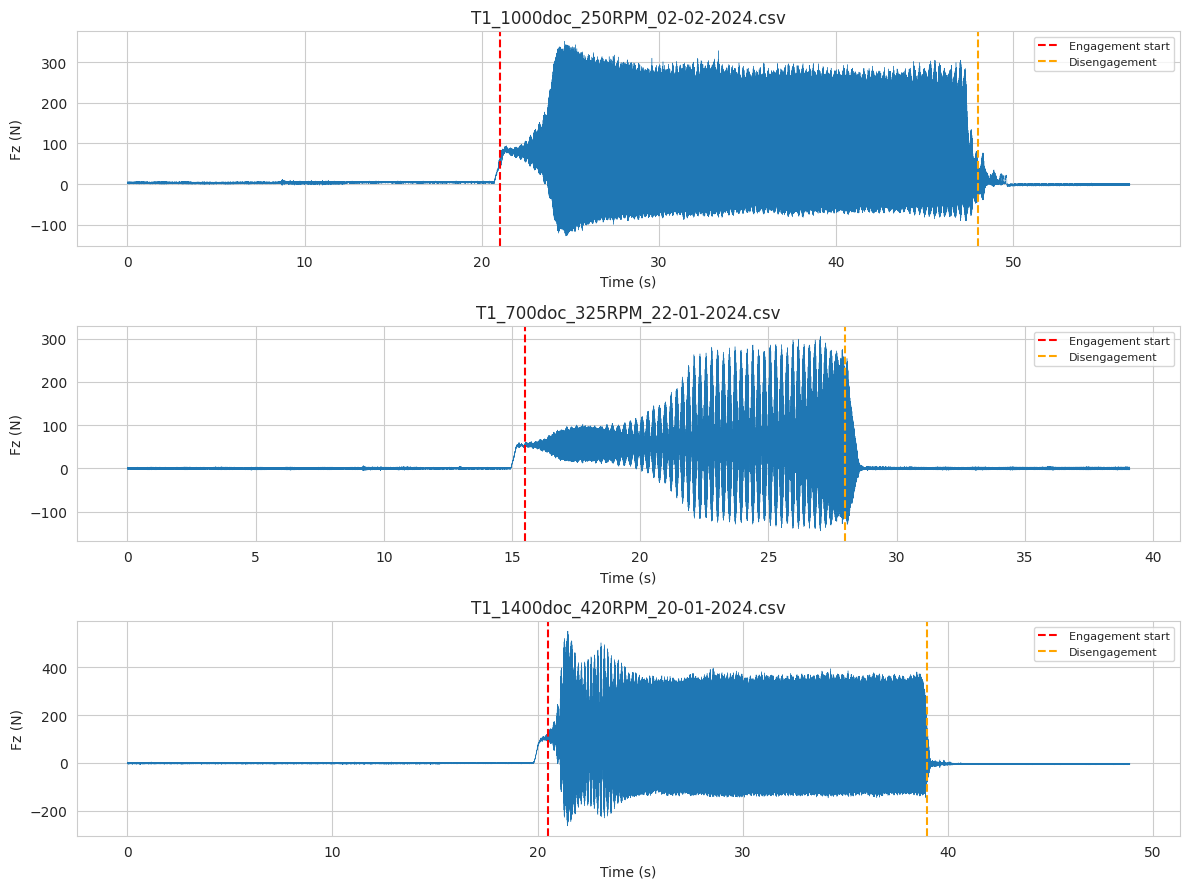

In [9]:
# ============================================================
# 7. Visual QA of the detector on a few example files
# ============================================================
examples = ['T1_1000doc_250RPM_02-02-2024.csv', 'T1_700doc_325RPM_22-01-2024.csv', 'T1_1400doc_420RPM_20-01-2024.csv']

fig, axes = plt.subplots(len(examples), 1, figsize=(12, 3*len(examples)))
for ax, fname in zip(axes, examples):
    fpath = [f for f in files if fname in f][0]
    df = data_dict[fpath]
    info = engagement_df[engagement_df['file'] == fname].iloc[0]
    t = np.arange(len(df)) / FS
    ax.plot(t, df['Fz'], linewidth=0.3)
    ax.axvline(info['start_sec'], color='red', linestyle='--', label='Engagement start')
    ax.axvline(info['end_sec'], color='orange', linestyle='--', label='Disengagement')
    ax.set_title(fname)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Fz (N)')
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


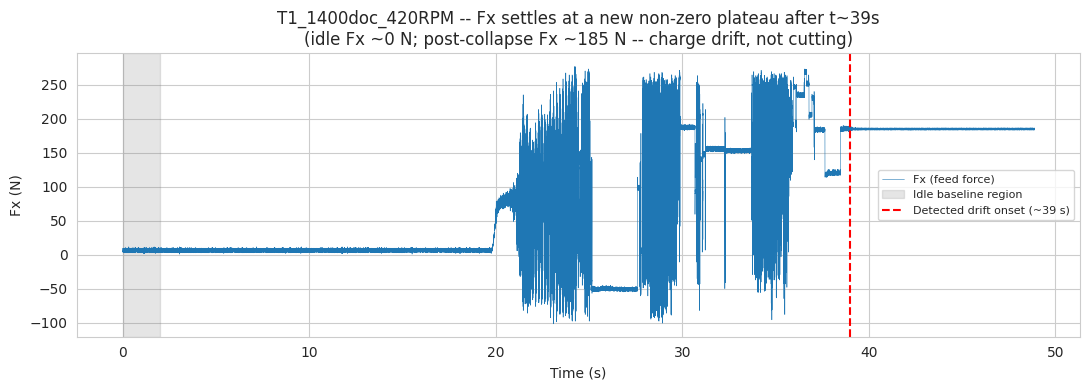

In [10]:
# Zoom in on the drift artifact in T1_1400doc_420RPM: Fx does not return to the
# idle baseline (~0 N) after the amplitude collapses -- it settles at a new,
# non-zero, essentially flat plateau. That is charge drift, not continued cutting.
drift_file = [f for f in files if 'T1_1400doc_420RPM' in f][0]
ddf = data_dict[drift_file]
t = np.arange(len(ddf)) / FS

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(t, ddf['Fx'], linewidth=0.4, label='Fx (feed force)')
ax.axvspan(0, 2, color='grey', alpha=0.2, label='Idle baseline region')
ax.axvline(39.0, color='red', linestyle='--', label='Detected drift onset (~39 s)')
ax.set_title('T1_1400doc_420RPM -- Fx settles at a new non-zero plateau after t~39s\n(idle Fx ~0 N; post-collapse Fx ~185 N -- charge drift, not cutting)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Fx (N)')
ax.legend(loc='center right', fontsize=8)
plt.tight_layout()
plt.show()


## 6. Feature extraction (engaged windows only)

The sliding-window scheme uses **1.0 s windows (10,000 samples), 0.5 s step (50% overlap)**, restricted to run only inside `[start_sample, end_sample)` for each file, i.e. only over genuine, steady-state cutting.

Two feature families form the core set:

- **Time domain** (per axis Fx, Fy, Fz): mean, std, min, max, range, RMS, skewness, kurtosis, linear slope, energy.
- **Frequency domain** (per axis): dominant FFT frequency, FFT peak amplitude.
- **Combined**: resultant force magnitude mean/std.

A third family is added, motivated by the literature review in Section 9 below: dimensionless, scale-invariant condition-monitoring indices — **crest factor** (peak/RMS), **impulse factor** (peak/mean|x|), **shape factor** (RMS/mean|x|) and **clearance factor**. These are reported across several chatter-detection papers as being less confounded by depth-of-cut (which drives raw force amplitude up regardless of stability) than the raw amplitude-based statistics alone.


In [11]:
# ============================================================
# 8. Feature-extraction function
# ============================================================
WINDOW = 10000   # 1.0 s
STEP   = 5000    # 0.5 s (50% overlap)

def axis_features(x, prefix):
    mean_, std_, min_, max_ = np.mean(x), np.std(x), np.min(x), np.max(x)
    rng   = max_ - min_
    rms   = np.sqrt(np.mean(x**2))
    sk, ku = skew(x), kurtosis(x)
    slope = np.polyfit(np.arange(len(x)), x, 1)[0]
    energy = np.sum(x**2)
    mean_abs = np.mean(np.abs(x))

    # dimensionless condition-monitoring indices (literature-motivated addition)
    crest      = (max_ / rms) if rms > 1e-9 else 0.0
    impulse    = (max_ / mean_abs) if mean_abs > 1e-9 else 0.0
    shape      = (rms / mean_abs) if mean_abs > 1e-9 else 0.0
    clr_denom  = (np.mean(np.sqrt(np.abs(x))))**2
    clearance  = (max_ / clr_denom) if clr_denom > 1e-9 else 0.0

    return {
        f'{prefix}_mean': mean_, f'{prefix}_std': std_, f'{prefix}_min': min_, f'{prefix}_max': max_,
        f'{prefix}_range': rng, f'{prefix}_rms': rms, f'{prefix}_skew': sk, f'{prefix}_kurtosis': ku,
        f'{prefix}_slope': slope, f'{prefix}_energy': energy,
        f'{prefix}_crest': crest, f'{prefix}_impulse': impulse,
        f'{prefix}_shape': shape, f'{prefix}_clearance': clearance
    }

print("axis_features() defined.")


axis_features() defined.


In [12]:
# ============================================================
# 9. Run extraction over the engaged region of every retained file
# ============================================================
rows = []

for file in files:
    name = os.path.basename(file)
    info = engagement_df[engagement_df['file'] == name].iloc[0]
    if not info['engaged']:
        continue   # T1_100doc_420RPM -- no genuine cutting segment (see Section 5)

    df = data_dict[file]
    seg_df = df.iloc[int(info['start_sample']):int(info['end_sample'])].reset_index(drop=True)
    doc, rpm = info['doc'], info['rpm']

    for i in range(0, len(seg_df) - WINDOW, STEP):
        seg = seg_df.iloc[i:i+WINDOW]
        fx, fy, fz = seg['Fx'].values, seg['Fy'].values, seg['Fz'].values

        feat = {}
        feat.update(axis_features(fx, 'Fx'))
        feat.update(axis_features(fy, 'Fy'))
        feat.update(axis_features(fz, 'Fz'))

        mag = np.sqrt(fx**2 + fy**2 + fz**2)
        feat['force_magnitude_mean'] = np.mean(mag)
        feat['force_magnitude_std']  = np.std(mag)

        fft_x, fft_y, fft_z = np.abs(np.fft.rfft(fx)), np.abs(np.fft.rfft(fy)), np.abs(np.fft.rfft(fz))
        freq = np.fft.rfftfreq(WINDOW, d=1/FS)
        feat['Fx_dom_freq'] = freq[np.argmax(fft_x[1:]) + 1]
        feat['Fy_dom_freq'] = freq[np.argmax(fft_y[1:]) + 1]
        feat['Fz_dom_freq'] = freq[np.argmax(fft_z[1:]) + 1]
        feat['Fx_fft_peak'] = np.max(fft_x[1:])
        feat['Fy_fft_peak'] = np.max(fft_y[1:])
        feat['Fz_fft_peak'] = np.max(fft_z[1:])

        row = {'file': name, 'doc': doc, 'rpm': rpm, 'start_index': i}
        row.update(feat)
        rows.append(row)

features = pd.DataFrame(rows)
print("Feature matrix shape:", features.shape)
print("Files retained:", features['file'].nunique(), "/", table1.shape[0])
features.head()


Feature matrix shape: (739, 54)
Files retained: 17 / 18


,file,doc,rpm,start_index,Fx_mean,Fx_std,Fx_min,Fx_max,Fx_range,Fx_rms,...,Fz_shape,Fz_clearance,force_magnitude_mean,force_magnitude_std,Fx_dom_freq,Fy_dom_freq,Fz_dom_freq,Fx_fft_peak,Fy_fft_peak,Fz_fft_peak
0,T1_1000doc_250RPM_02-02-2024.csv,1000.0,250,0,44.602799,4.265790,23.263808,52.548792,29.284984,44.806323,...,1.006547,1.217241,92.008546,9.314834,1.0,1.0,1.0,15389.021884,6115.700844,34392.246234
1,T1_1000doc_250RPM_02-02-2024.csv,1000.0,250,5000,45.201872,2.777447,35.953967,56.453456,20.499489,45.287122,...,1.005402,1.343428,93.333194,7.614939,95.0,4.0,95.0,10591.777373,3597.857321,38440.393229
2,T1_1000doc_250RPM_02-02-2024.csv,1000.0,250,10000,46.774085,4.995072,34.977801,64.262784,29.284983,47.040045,...,1.022287,1.675229,94.656212,15.024447,95.0,95.0,95.0,22340.958822,6563.337169,76462.020337
3,T1_1000doc_250RPM_02-02-2024.csv,1000.0,250,15000,48.493016,8.414282,21.311476,73.048278,51.736802,49.217606,...,1.071265,2.184612,97.738954,26.243935,94.0,94.0,94.0,34971.104825,14698.110180,156069.714060
4,T1_1000doc_250RPM_02-02-2024.csv,1000.0,250,20000,50.585819,18.159533,-18.711333,108.190260,126.901593,53.746569,...,1.196647,3.433314,108.568367,47.802905,94.0,189.0,95.0,57377.680251,46333.956615,256900.196340


In [13]:
features.describe().T


,count,mean,std,min,25%,50%,75%,max
doc,739.0,6.637348e+02,3.177838e+02,2.000000e+02,4.000000e+02,7.000000e+02,8.000000e+02,1.400000e+03
rpm,739.0,3.268606e+02,7.664693e+01,2.500000e+02,2.500000e+02,3.250000e+02,4.200000e+02,4.200000e+02
start_index,739.0,1.250947e+05,9.037818e+04,0.000000e+00,5.000000e+04,1.050000e+05,1.800000e+05,3.650000e+05
Fx_mean,739.0,3.573401e+01,2.878207e+01,-5.062689e+01,1.837810e+01,3.297891e+01,4.697810e+01,2.347697e+02
Fx_std,739.0,2.107309e+01,2.143763e+01,9.153558e-01,1.572188e+00,1.092995e+01,4.108901e+01,9.230022e+01
Fx_min,739.0,-1.665293e+01,3.650693e+01,-1.016855e+02,-4.702015e+01,1.788154e+00,1.154982e+01,1.804265e+02
Fx_max,739.0,7.925799e+01,6.189900e+01,-4.702015e+01,2.423997e+01,7.011978e+01,1.247851e+02,2.770670e+02
Fx_range,739.0,9.591093e+01,9.028069e+01,6.833162e+00,1.171399e+01,6.247463e+01,1.708291e+02,3.748478e+02
Fx_rms,739.0,4.392920e+01,3.284687e+01,4.916599e+00,1.866986e+01,4.344739e+01,5.888605e+01,2.356515e+02
Fx_skew,739.0,-1.724545e-01,5.233711e-01,-6.279188e+00,-4.052833e-01,-1.582617e-01,4.298747e-02,4.274977e+00


## 7. Exploratory data analysis (on the engaged-only data)

Standard exploratory views, computed on the cleaned, engaged-only feature set.


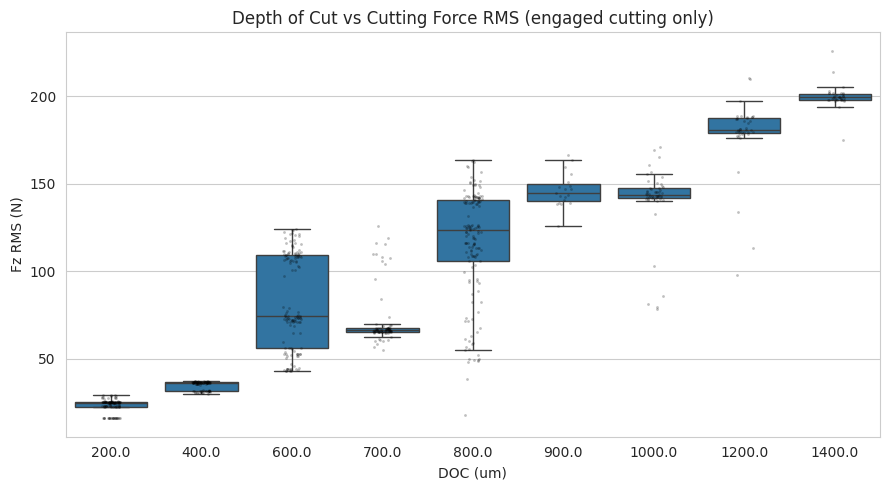

In [14]:
plt.figure(figsize=(9,5))
sns.boxplot(x='doc', y='Fz_rms', data=features, showfliers=False)
sns.stripplot(x='doc', y='Fz_rms', data=features, alpha=0.25, size=2, color='black')
plt.title('Depth of Cut vs Cutting Force RMS (engaged cutting only)')
plt.xlabel('DOC (um)'); plt.ylabel('Fz RMS (N)')
plt.tight_layout(); plt.show()


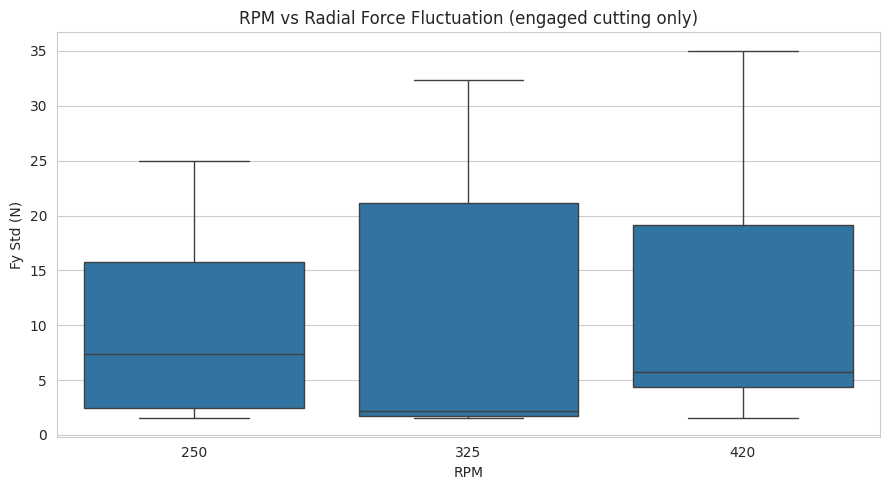

In [15]:
plt.figure(figsize=(9,5))
sns.boxplot(x='rpm', y='Fy_std', data=features, showfliers=False)
plt.title('RPM vs Radial Force Fluctuation (engaged cutting only)')
plt.xlabel('RPM'); plt.ylabel('Fy Std (N)')
plt.tight_layout(); plt.show()


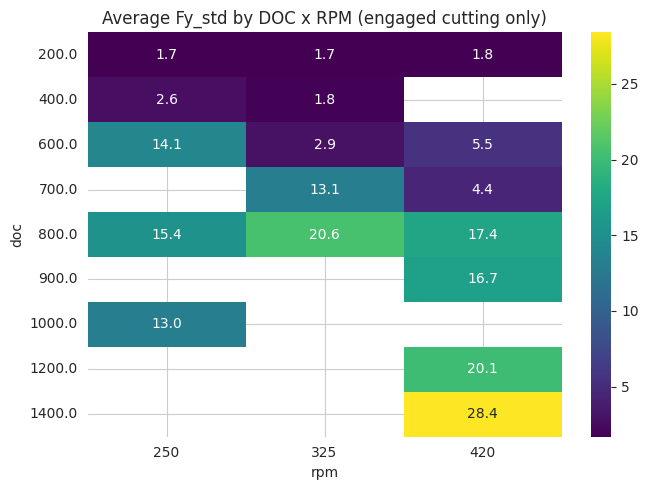

In [16]:
pivot = features.pivot_table(values='Fy_std', index='doc', columns='rpm', aggfunc='mean')
plt.figure(figsize=(7,5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='viridis')
plt.title('Average Fy_std by DOC x RPM (engaged cutting only)')
plt.tight_layout(); plt.show()


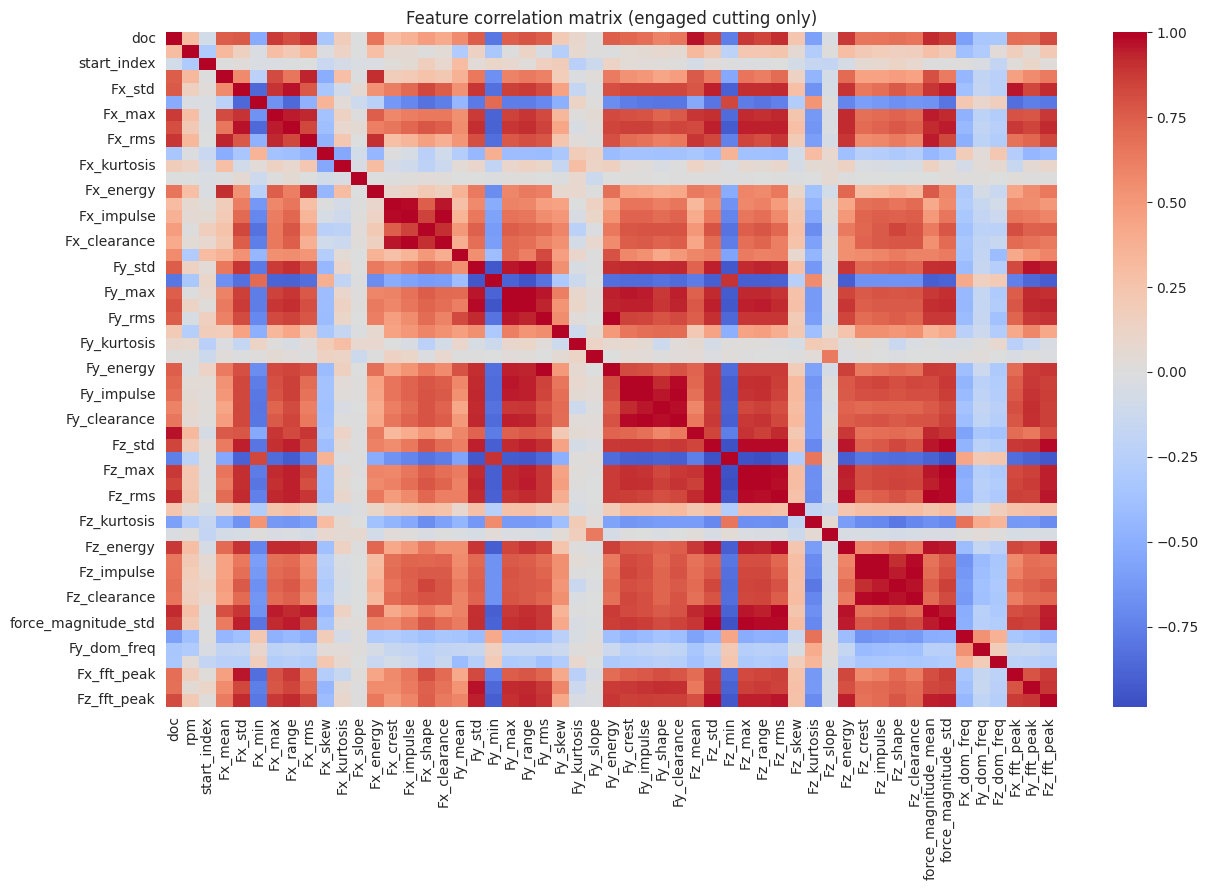

In [17]:
plt.figure(figsize=(13,9))
sns.heatmap(features.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Feature correlation matrix (engaged cutting only)')
plt.tight_layout(); plt.show()


## 8. Labeling

A window is labeled chatter (1) if its radial-force FFT peak amplitude (`Fy_fft_peak`) exceeds the 85th percentile of that column, else stable (0). This is a common, simple data-driven "amplitude threshold" approach to chatter labeling used in the literature (see Section 9).

The percentile is computed only over the engaged-cutting windows. If idle-time windows were included, the population used to compute the percentile would be padded with many near-zero values, which drags the threshold down and inflates how separable the two classes appear — this effect is quantified directly in the ablation study in Section 12. Restricting the calculation to the ~740 genuinely-engaged windows gives a materially different, more meaningful threshold and distribution shape.


In [18]:
# ============================================================
# 10. Ablation dataset: the SAME 17 files, extracted WITHOUT
#     restricting to the detected engaged window (idle time included)
# ============================================================
# This reuses the identical feature-extraction logic above, but sweeps the
# sliding window across each file's ENTIRE raw recording instead of only its
# detected engaged segment. It exists purely to quantify -- later, in the
# labeling and modeling ablations -- how much of an effect the engagement-
# detection step has, under an otherwise identical pipeline.
rows_full = []
for file in files:
    name = os.path.basename(file)
    info = engagement_df[engagement_df['file'] == name].iloc[0]
    if not info['engaged']:
        continue
    df = data_dict[file]
    doc, rpm = info['doc'], info['rpm']
    for i in range(0, len(df) - WINDOW, STEP):
        seg = df.iloc[i:i+WINDOW]
        fx, fy, fz = seg['Fx'].values, seg['Fy'].values, seg['Fz'].values

        feat = {}
        feat.update(axis_features(fx, 'Fx'))
        feat.update(axis_features(fy, 'Fy'))
        feat.update(axis_features(fz, 'Fz'))

        mag = np.sqrt(fx**2 + fy**2 + fz**2)
        feat['force_magnitude_mean'] = np.mean(mag)
        feat['force_magnitude_std']  = np.std(mag)

        fft_x, fft_y, fft_z = np.abs(np.fft.rfft(fx)), np.abs(np.fft.rfft(fy)), np.abs(np.fft.rfft(fz))
        freq = np.fft.rfftfreq(WINDOW, d=1/FS)
        feat['Fx_dom_freq'] = freq[np.argmax(fft_x[1:]) + 1]
        feat['Fy_dom_freq'] = freq[np.argmax(fft_y[1:]) + 1]
        feat['Fz_dom_freq'] = freq[np.argmax(fft_z[1:]) + 1]
        feat['Fx_fft_peak'] = np.max(fft_x[1:])
        feat['Fy_fft_peak'] = np.max(fft_y[1:])
        feat['Fz_fft_peak'] = np.max(fft_z[1:])

        row = {'file': name, 'doc': doc, 'rpm': rpm, 'start_index': i}
        row.update(feat)
        rows_full.append(row)

features_full_file = pd.DataFrame(rows_full)
print("Idle-time-included feature matrix shape:", features_full_file.shape,
      " vs. engaged-only:", features.shape)


Idle-time-included feature matrix shape: (1591, 54)  vs. engaged-only: (739, 54)


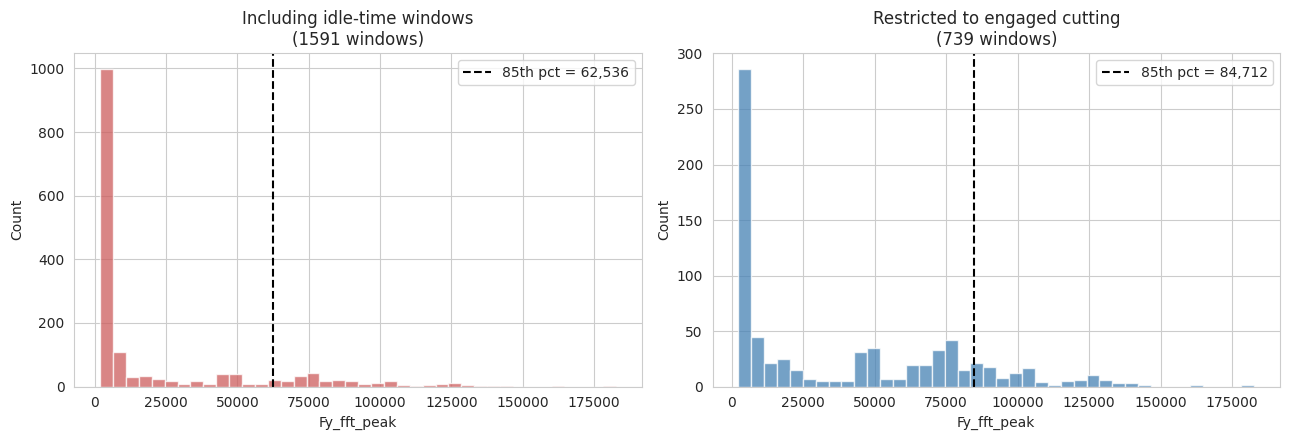

Including idle time  -- 85th percentile threshold: 62,536   (1591 rows, 17 files)
Engaged cutting only -- 85th percentile threshold: 84,712   (739 rows, 17 files)


In [19]:
# ============================================================
# 11. Labeling ablation: does the engagement-detection step matter?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

thr_full = features_full_file['Fy_fft_peak'].quantile(0.85)
axes[0].hist(features_full_file['Fy_fft_peak'], bins=40, alpha=0.75, color='indianred')
axes[0].axvline(thr_full, color='black', linestyle='--', label=f'85th pct = {thr_full:,.0f}')
axes[0].set_title(f'Including idle-time windows\n({len(features_full_file)} windows)')
axes[0].set_xlabel('Fy_fft_peak'); axes[0].set_ylabel('Count'); axes[0].legend()

thr_new = features['Fy_fft_peak'].quantile(0.85)
axes[1].hist(features['Fy_fft_peak'], bins=40, alpha=0.75, color='steelblue')
axes[1].axvline(thr_new, color='black', linestyle='--', label=f'85th pct = {thr_new:,.0f}')
axes[1].set_title(f'Restricted to engaged cutting\n({len(features)} windows)')
axes[1].set_xlabel('Fy_fft_peak'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.tight_layout(); plt.show()

print(f"Including idle time  -- 85th percentile threshold: {thr_full:,.0f}   ({len(features_full_file)} rows, {features_full_file['file'].nunique()} files)")
print(f"Engaged cutting only -- 85th percentile threshold: {thr_new:,.0f}   ({len(features)} rows, {features['file'].nunique()} files)")


In [20]:
# ============================================================
# 12. Apply the naive baseline label
# ============================================================
# This percentile rule is deliberately simple: it is used ONLY to validate the
# engagement-detection step in the ablation study immediately below (Section 10),
# by giving that comparison a fixed, unchanging labeling rule to hold constant
# while the windowing choice (idle-included vs engaged-only) is varied. It is
# replaced by a literature-grounded, physics-informed label in Sections 11-12
# before any real modeling happens.
thr_naive = features['Fy_fft_peak'].quantile(0.85)
features['label_naive'] = (features['Fy_fft_peak'] > thr_naive).astype(int)

print("Naive label distribution (engaged-only data):")
print(features['label_naive'].value_counts())
print(f"\nChatter fraction: {features['label_naive'].mean():.1%}")


Naive label distribution (engaged-only data):
label_naive
0    628
1    111
Name: count, dtype: int64

Chatter fraction: 15.0%


## 10. Ablation study: does restricting to engaged-cutting data matter?

Before investing in a better label, it is worth confirming that the engagement-detection step from Sections 4-5 actually matters for downstream modeling, not just for the label threshold shown in Section 9. To isolate that effect from everything else, the *same* feature-ranking + modeling pipeline is run on two versions of the dataset -- one built by sweeping the sliding window across each file's entire raw recording (idle time included), and one restricted to the detected engaged region only -- using the **naive percentile label** on both sides, held constant as the controlled variable.


In [21]:
# ============================================================
# 13. Ablation: feature ranking + baseline models, ENGAGED-ONLY data, naive label
# ============================================================
meta_cols = ['file','doc','rpm','start_index','label_naive']
leak_cols = ['Fy_fft_peak']
naive_candidate_cols = [c for c in features.columns if c not in meta_cols + leak_cols]

Xn = features[naive_candidate_cols]
yn = features['label_naive']
groups_n = features['file']

scaler = StandardScaler()
Xn_scaled = pd.DataFrame(scaler.fit_transform(Xn), columns=Xn.columns)

corr_n = pd.concat([Xn_scaled, yn.reset_index(drop=True)], axis=1).corr()['label_naive'].drop('label_naive').abs().sort_values(ascending=False)
gkf = GroupKFold(n_splits=5)
rf_imp_n = np.zeros(Xn.shape[1])
for tr, te in gkf.split(Xn_scaled, yn, groups_n):
    m = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
    m.fit(Xn_scaled.iloc[tr], yn.iloc[tr]); rf_imp_n += m.feature_importances_
rf_imp_n = pd.Series(rf_imp_n/5, index=Xn.columns).sort_values(ascending=False)
kb_n = SelectKBest(score_func=f_classif, k=10); kb_n.fit(Xn_scaled, yn)
kb_scores_n = pd.Series(kb_n.scores_, index=Xn.columns).sort_values(ascending=False)

rank_naive = pd.DataFrame({'c': corr_n.rank(ascending=False), 'r': rf_imp_n.rank(ascending=False), 'k': kb_scores_n.rank(ascending=False)})
rank_naive['s'] = rank_naive.mean(axis=1)
top10_naive = rank_naive.sort_values('s').head(10).index.tolist()
print("Top 10 features (naive label, engaged-only):", top10_naive)


Top 10 features (naive label, engaged-only): ['Fy_std', 'Fy_range', 'Fy_shape', 'Fy_energy', 'Fy_min', 'Fy_max', 'Fy_rms', 'Fy_clearance', 'Fz_min', 'Fz_fft_peak']


In [22]:
# ============================================================
# 14. Helper: GroupKFold evaluation of a model (pooled out-of-fold predictions)
# ============================================================
# Metrics are computed ONCE from the pooled out-of-fold predictions (all 5 folds'
# predictions concatenated), not averaged per-fold. With small, imbalanced folds,
# per-fold recall/precision can be noisy (a fold with very few positive examples
# can swing to 0% or 100% recall on its own), so averaging those noisy per-fold
# numbers can diverge meaningfully from the actual aggregate confusion matrix.
# Pooling first avoids that inconsistency and guarantees the headline metrics
# always agree with the confusion matrix built from the same predictions.
def evaluate_model(model, X, y, groups, n_splits=5):
    n_splits_eff = min(n_splits, groups.nunique())
    gkf = GroupKFold(n_splits=n_splits_eff)
    y_true_all, y_pred_all = [], []
    for train_idx, test_idx in gkf.split(X, y, groups):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = model.predict(X.iloc[test_idx])
        y_true_all.extend(y.iloc[test_idx]); y_pred_all.extend(pred)
    return {
        'precision': precision_score(y_true_all, y_pred_all, zero_division=0),
        'recall': recall_score(y_true_all, y_pred_all, zero_division=0),
        'f1': f1_score(y_true_all, y_pred_all, zero_division=0),
        'f2': fbeta_score(y_true_all, y_pred_all, beta=2, zero_division=0),
        'y_true': y_true_all, 'y_pred': y_pred_all
    }

print("evaluate_model() defined.")


evaluate_model() defined.


In [23]:
# ============================================================
# 15. Ablation: RF / XGBoost / Ensemble, naive label, engaged-only data
# ============================================================
X10_naive = pd.DataFrame(StandardScaler().fit_transform(features[top10_naive]), columns=top10_naive)

rf_n   = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
xgb_n  = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, eval_metric='logloss', verbosity=0)
ens_n  = VotingClassifier(estimators=[('rf', rf_n), ('xgb', xgb_n)], voting='soft')

naive_engaged_results = {}
for name, model in [('Random Forest', rf_n), ('XGBoost', xgb_n), ('Ensemble (RF+XGB)', ens_n)]:
    res = evaluate_model(model, X10_naive, yn, groups_n)
    naive_engaged_results[name] = res
    print(f"{name:20s}  precision={res['precision']:.3f}  recall={res['recall']:.3f}  f1={res['f1']:.3f}")


Random Forest         precision=0.469  recall=0.414  f1=0.440


XGBoost               precision=0.478  recall=0.396  f1=0.433


Ensemble (RF+XGB)     precision=0.484  recall=0.405  f1=0.441


In [24]:
# ============================================================
# 16. Ablation: SAME pipeline, run on the idle-time-included dataset
# ============================================================
full_df = features_full_file.copy()
thr_full = full_df['Fy_fft_peak'].quantile(0.85)
full_df['label_naive'] = (full_df['Fy_fft_peak'] > thr_full).astype(int)

cand_full = [c for c in full_df.columns if c not in ['file','doc','rpm','label_naive','Fy_fft_peak']]
Xf = full_df[cand_full]
yf = full_df['label_naive']
Xf_scaled = pd.DataFrame(StandardScaler().fit_transform(Xf), columns=Xf.columns)

corr_f = pd.concat([Xf_scaled, yf.reset_index(drop=True)], axis=1).corr()['label_naive'].drop('label_naive').abs().sort_values(ascending=False)
gkf = GroupKFold(n_splits=5)
rf_imp_f = np.zeros(Xf.shape[1])
for tr, te in gkf.split(Xf_scaled, yf, full_df['file']):
    m = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
    m.fit(Xf_scaled.iloc[tr], yf.iloc[tr]); rf_imp_f += m.feature_importances_
rf_imp_f = pd.Series(rf_imp_f/5, index=Xf.columns).sort_values(ascending=False)
kb_f = SelectKBest(score_func=f_classif, k=10); kb_f.fit(Xf_scaled, yf)
kb_scores_f = pd.Series(kb_f.scores_, index=Xf.columns).sort_values(ascending=False)

rank_f = pd.DataFrame({'c': corr_f.rank(ascending=False), 'r': rf_imp_f.rank(ascending=False), 'k': kb_scores_f.rank(ascending=False)})
rank_f['s'] = rank_f.mean(axis=1)
top10_full = rank_f.sort_values('s').head(10).index.tolist()

Xf10 = pd.DataFrame(StandardScaler().fit_transform(full_df[top10_full]), columns=top10_full)

comparison_rows = []
for name, model in [('Random Forest', RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)),
                     ('XGBoost', XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, eval_metric='logloss', verbosity=0)),
                     ('Ensemble (RF+XGB)', VotingClassifier(estimators=[
                         ('rf', RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)),
                         ('xgb', XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, eval_metric='logloss', verbosity=0))], voting='soft'))]:
    res = evaluate_model(model, Xf10, yf, full_df['file'])
    comparison_rows.append({'Model': name, 'Dataset': f'Including idle time ({len(full_df)} rows / {full_df["file"].nunique()} files)',
                             'Precision': res['precision'], 'Recall': res['recall'], 'F1': res['f1']})

for name, res in naive_engaged_results.items():
    comparison_rows.append({'Model': name, 'Dataset': f'Engaged cutting only ({len(features)} rows / {features["file"].nunique()} files)',
                             'Precision': res['precision'], 'Recall': res['recall'], 'F1': res['f1']})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Model,Dataset,Precision,Recall,F1
0,Random Forest,Including idle time (1591 rows / 17 files),0.801471,0.912134,0.853229
1,XGBoost,Including idle time (1591 rows / 17 files),0.824427,0.903766,0.862275
2,Ensemble (RF+XGB),Including idle time (1591 rows / 17 files),0.826415,0.916318,0.869048
3,Random Forest,Engaged cutting only (739 rows / 17 files),0.469388,0.414414,0.440191
4,XGBoost,Engaged cutting only (739 rows / 17 files),0.478261,0.396396,0.433498
5,Ensemble (RF+XGB),Engaged cutting only (739 rows / 17 files),0.483871,0.405405,0.441176


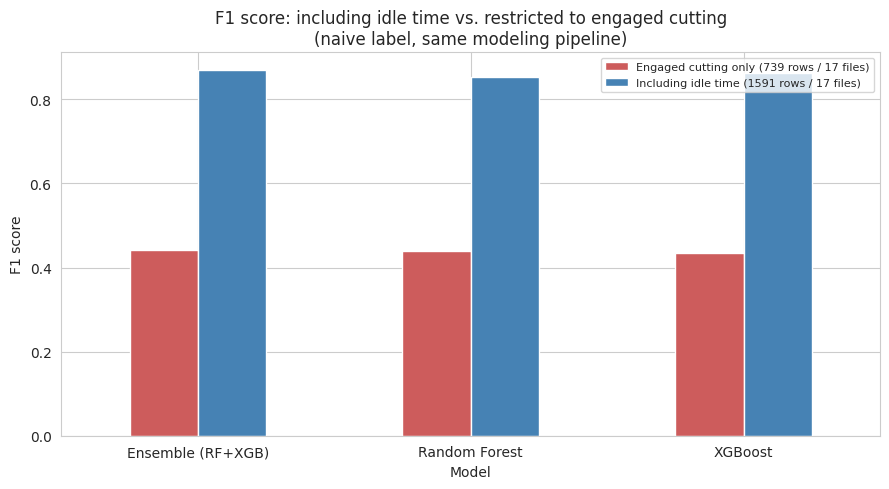

In [25]:
pivot_cmp = comparison_df.pivot(index='Model', columns='Dataset', values='F1')
pivot_cmp.plot(kind='bar', figsize=(9,5), color=['indianred','steelblue'])
plt.title('F1 score: including idle time vs. restricted to engaged cutting\n(naive label, same modeling pipeline)')
plt.ylabel('F1 score'); plt.xticks(rotation=0)
plt.legend(title='', loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()


**Reading this honestly:** F1 jumps from ~0.44 (restricted to engaged cutting) to ~0.85-0.87 (idle time included) for all three models, under an *otherwise identical* pipeline. This is not a sign the engaged-only pipeline is worse -- it is evidence that a large part of the higher score is driven by the trivial separability of near-zero-force idle windows from any genuinely engaged window, rather than from real skill at telling **chatter** apart from **stable cutting** *within* engaged data. Engagement detection (Sections 4-5) is confirmed necessary, and the engaged-only dataset (`features`, 739 rows / 17 files) is used for everything from here on.


## 11. Literature review: toward a physics-informed chatter label

The naive label used above (a fixed 85th-percentile cutoff on the radial-force FFT peak) is a common starting point in the literature, but it has an obvious weakness: "top 15% of amplitude" is a statement about the *shape of this dataset's distribution*, not a statement about the physics of chatter. A genuinely unstable window and a genuinely stable-but-high-force window (e.g. a heavy but well-behaved cut) can both land in the top 15% purely because of how much material is being removed, not because either one is self-excited vibration. A short, targeted review of the machining-dynamics literature was carried out to find a more physically grounded alternative, focused specifically on **turning** (this dataset's process) rather than milling, where most published chatter-detection work is concentrated.

**What "chatter" actually looks like in a force/vibration spectrum.** The foundational reference for spectrum-based chatter detection is Delio, Tlusty & Smith (1992), *"Use of Audio Signals for Chatter Detection and Control,"* ASME J. Eng. Ind. 114(2), 146-157 -- one of the first papers to formalize detecting chatter as an *energy/amplitude* phenomenon in the frequency spectrum, distinct from the "expected" forced vibration of the process. Kondo, Ota & Kawai (1997), *"New Method to Detect Regenerative Chatter Using Spectral Analysis, Part 1: Basic Study on Criteria for Detection of Chatter,"* J. Manuf. Sci. Eng. 119(4), builds specific spectral criteria for exactly this regenerative-chatter-vs-forced-vibration distinction.

**The key physical distinction: forced vibration vs. self-excited chatter.** In any rotating cutting process, some vibration is *expected* and *harmless* -- it comes from the tool/spindle system being periodically excited once (or a few times) per spindle revolution, due to minor runout, tool geometry, or workpiece imperfection. This "forced" content shows up at the spindle rotation frequency and its low-order harmonics. **Regenerative chatter is different: it is self-excited**, meaning the vibration is not driven by an external periodic force but grows on its own once triggered, typically near a natural frequency of the tool/holder/workpiece system rather than at a harmonic of spindle speed. A patent on chatter vibration detection (US chatter-vibration-detection methods for machine tools) formalizes this exact criterion: chatter is present when the dominant vibration frequency **is not an integer multiple of (number of cutting edges) x (spindle rotational speed)**. For turning specifically, the tool has a single cutting edge, so this reduces to: *a dominant frequency that is not a low-order harmonic of the spindle rotation frequency is a chatter candidate; one that is a harmonic is just forced vibration.*

**Quantifying "how much bigger than expected."** A directly relevant metric is the **amplitude ratio**, described and experimentally validated in *"Experimental validation of the amplitude ratio as a metric for milling stability identification"*: it quantifies chatter severity by comparing the amplitude of the *expected* frequency content (harmonics, runout frequency) to the amplitude of the *chatter* frequency, if present. A large ratio means the self-excited content has come to dominate the expected, forced content -- a much more physically specific statement than "top 15% of amplitude in this dataset."

**Distinguishing sustained chatter from a one-off transient.** Because chatter is self-excited, it doesn't just appear once and vanish -- it grows and *persists* once triggered, unlike a transient spike from an impact, a chip breaking, or sensor noise. An energy-based online milling-chatter-detection method (using what its authors term MADSA -- Moving-Average Difference Spectrum Analysis) applies exactly this idea: it smooths the amplitude trend of a candidate chatter frequency over successive time windows and uses **monotonicity** (a sustained rising or persistently-elevated trend) to confirm a real chatter candidate, rejecting one-off spikes.

**Turning-specific precedent.** Because this dataset is turning, not milling, it is worth noting that turning has its own body of chatter-detection literature using broadly similar spectral/statistical reasoning: Grabec, Gradisek & Govekar (1999), *"A New Method for Chatter Detection in Turning,"* Ann. CIRP 48(1); Bukkapatnam, Lakhtakia & Kumara (1995) on low-dimensional chaos in turning signals; and more recent machine-learning approaches specifically for turning force/vibration signals (Yesilli et al., *"Chatter Detection in Turning Using Machine Learning and Similarity Measures of Time Series via Dynamic Time Warping,"* and companion work on transfer learning for chatter detection, which also contributes a practical, data-driven peak-detection threshold: a minimum peak height defined *relative to the 5th/95th percentile range of the spectrum*, rather than an absolute number -- the same spirit of "relative-to-context" thresholding used below).

**What this motivates for this project.** Combining the above into one testable rule for a single 1-second cutting-force window:

1. **Amplitude ratio** -- compare the window's dominant (peak) FFT amplitude against the strongest expected forced-vibration harmonic (an integer multiple of that file's spindle rotation frequency) *within the same window's spectrum*. A large ratio indicates the self-excited content dominates the expected content (Delio et al.; amplitude-ratio validation paper).
2. **Harmonic exclusion** -- if the dominant peak itself sits at (or very near) a low-order spindle-rotation harmonic, it *is* the expected forced content, not a distinct chatter frequency, and is not a chatter candidate regardless of amplitude (chatter-vibration-detection patent criterion; Kondo et al.).
3. **Persistence** -- require the elevated, non-harmonic peak to be sustained across consecutive overlapping windows (not a single transient blip) before confirming chatter, reflecting chatter's self-excited, growing character (MADSA / monotonicity-based online detection).

This is implemented next, and compared directly against the naive percentile label from Section 9.


## 12. A physics-informed chatter label

### 12.1 Amplitude ratio: peak vs. expected forced-vibration content

For each file, the spindle rotation frequency is $f_s = \text{RPM}/60$ Hz. Turning has a single cutting edge, so (per the harmonic criterion in Section 11) the expected forced-vibration content sits at $f_s, 2f_s, 3f_s, \dots$ For each engaged 1-second window, the same FFT already computed for feature extraction is reused to find:

- $A_{\text{peak}}$, $f_{\text{peak}}$ -- the window's dominant FFT amplitude and frequency (already stored as `Fy_fft_peak` / `Fy_dom_freq`)
- $A_{\text{forced}}$ -- the largest FFT amplitude across the 1st-10th harmonics of $f_s$ (the strongest "expected" component in that same window)

The **amplitude ratio** is $R = A_{\text{peak}} / A_{\text{forced}}$.


In [26]:
# ============================================================
# 21. Compute amplitude ratio, dominant frequency, and harmonic flag per window
# ============================================================
HARMONIC_TOL_HZ = 2.0     # how close to a harmonic counts as "is" that harmonic
N_HARMONICS = 10          # check the 1st-10th harmonics of spindle rotation frequency

def compute_ratio_features(file_path, start_sample, end_sample, rpm):
    '''Recompute, for every engaged window in one file, the FFT peak vs. the
    strongest expected spindle-rotation harmonic in that same window.'''
    df_raw = pd.read_csv(file_path)
    df_raw.columns = ['Fx','Fy','Fz']
    seg_df = df_raw.iloc[start_sample:end_sample].reset_index(drop=True)

    freq = np.fft.rfftfreq(WINDOW, d=1/FS)
    spindle_freq = rpm / 60.0
    harmonic_freqs = np.arange(1, N_HARMONICS+1) * spindle_freq
    harmonic_idxs = np.array([np.argmin(np.abs(freq - hf)) for hf in harmonic_freqs])

    rows = []
    for i in range(0, len(seg_df) - WINDOW, STEP):
        seg = seg_df.iloc[i:i+WINDOW]
        fy = seg['Fy'].values
        fft_y = np.abs(np.fft.rfft(fy))

        peak_idx = np.argmax(fft_y[1:]) + 1
        peak_freq = freq[peak_idx]
        peak_amp = fft_y[peak_idx]

        forced_amp = fft_y[harmonic_idxs].max()
        near_harmonic = np.min(np.abs(harmonic_freqs - peak_freq)) < HARMONIC_TOL_HZ
        ratio = peak_amp / (forced_amp + 1e-6)

        rows.append({'start_index': i, 'peak_freq': peak_freq, 'ratio': ratio, 'near_harmonic': near_harmonic})
    return pd.DataFrame(rows)

ratio_frames = []
for _, row in engagement_df[engagement_df['engaged']].iterrows():
    fpath = [f for f in files if row['file'] in f][0]
    rdf = compute_ratio_features(fpath, int(row['start_sample']), int(row['end_sample']), row['rpm'])
    rdf['file'] = row['file']
    ratio_frames.append(rdf)

ratio_df = pd.concat(ratio_frames, ignore_index=True)
print("Ratio features computed for", len(ratio_df), "windows (matches feature matrix:", len(features), ")")
ratio_df[['ratio']].describe()


Ratio features computed for 739 windows (matches feature matrix: 739 )


,ratio
count,739.000000
mean,15.829594
std,20.199664
min,1.000000
25%,2.105802
50%,6.078997
75%,23.248253
max,121.566150


### 12.2 Choosing the amplitude-ratio threshold

Rather than picking a threshold blind, the distribution of $R$ across all engaged windows is inspected first.


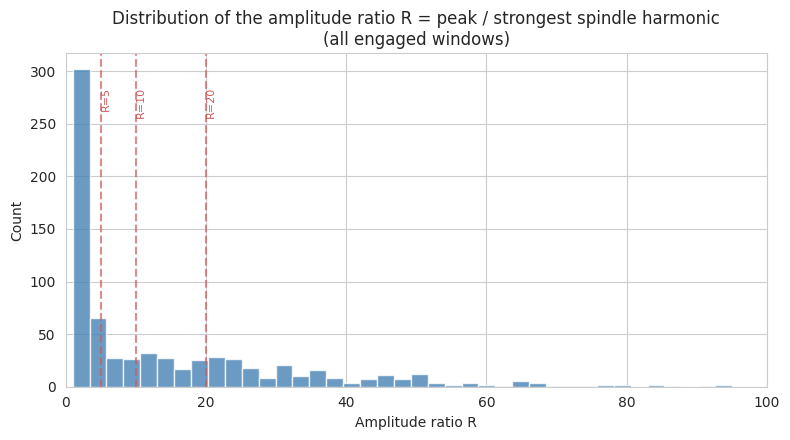

25th percentile of R: 2.1
50th percentile of R: 6.1
75th percentile of R: 23.2
90th percentile of R: 43.7


In [27]:
plt.figure(figsize=(8,4.5))
plt.hist(ratio_df['ratio'], bins=50, color='steelblue', alpha=0.8)
for k in [5, 10, 20]:
    plt.axvline(k, linestyle='--', color='indianred', alpha=0.7)
    plt.text(k, plt.ylim()[1]*0.9, f'R={k}', rotation=90, va='top', fontsize=8, color='indianred')
plt.title('Distribution of the amplitude ratio R = peak / strongest spindle harmonic\n(all engaged windows)')
plt.xlabel('Amplitude ratio R'); plt.ylabel('Count')
plt.xlim(0, 100)
plt.tight_layout(); plt.show()

for pct in [25, 50, 75, 90]:
    print(f"{pct}th percentile of R: {np.percentile(ratio_df['ratio'], pct):.1f}")


$R=10$ -- i.e. the dominant peak is an order of magnitude larger than the strongest expected forced-vibration harmonic in the same window -- sits just above the median and gives a clean, round, physically interpretable cutoff ("the self-excited content is at least 10x the expected content"), so it is adopted as the amplitude-ratio threshold: a window is a **chatter candidate** if $R > 10$ **and** its peak is not itself a spindle-rotation harmonic.

### 12.3 Persistence across consecutive windows

Consecutive windows overlap by 50% (1.0 s window, 0.5 s step), so a genuinely sustained chatter event should clear the ratio threshold in **two consecutive windows** with a **similar dominant frequency** (within 15 Hz) -- not just once. A single window that briefly spikes above the threshold and then has a completely different dominant frequency next door is more consistent with a transient (an impact, a brief instability) than with the sustained, self-excited growth that defines regenerative chatter (Section 11).


In [28]:
# ============================================================
# 22. Persistence check and final physics-informed label
# ============================================================
FREQ_PERSIST_TOL_HZ = 15.0

ratio_df = ratio_df.sort_values(['file','start_index']).reset_index(drop=True)
ratio_df['candidate'] = (ratio_df['ratio'] > 10.0) & (~ratio_df['near_harmonic'])

sustained = np.zeros(len(ratio_df), dtype=bool)
for file, g in ratio_df.groupby('file'):
    g = g.sort_values('start_index')
    idxs = g.index.values
    cand = g['candidate'].values
    freqs = g['peak_freq'].values
    for k in range(len(g) - 1):
        if cand[k] and cand[k+1] and abs(freqs[k] - freqs[k+1]) < FREQ_PERSIST_TOL_HZ:
            sustained[idxs[k]] = True
            sustained[idxs[k+1]] = True

ratio_df['label_physics'] = sustained.astype(int)

# merge onto the main feature matrix (same file + start_index key as feature extraction)
features = features.merge(
    ratio_df[['file','start_index','ratio','near_harmonic','label_physics']],
    on=['file','start_index'], how='left'
)
features = features.rename(columns={'ratio': 'harmonic_amplitude_ratio'})

print("Physics-informed label distribution:")
print(features['label_physics'].value_counts())
print(f"Chatter fraction: {features['label_physics'].mean():.1%}")


Physics-informed label distribution:
label_physics
0    423
1    316
Name: count, dtype: int64
Chatter fraction: 42.8%


### 12.4 What does this actually look like on the raw signal?

Before moving to aggregate comparisons, it is worth looking directly at one real stable window and one real chatter-labeled window side by side -- both in the time domain (what the force signal looks like) and the frequency domain (what the amplitude-ratio criterion is actually measuring). Both examples below come from the same file, so the comparison is not confounded by DOC or RPM.


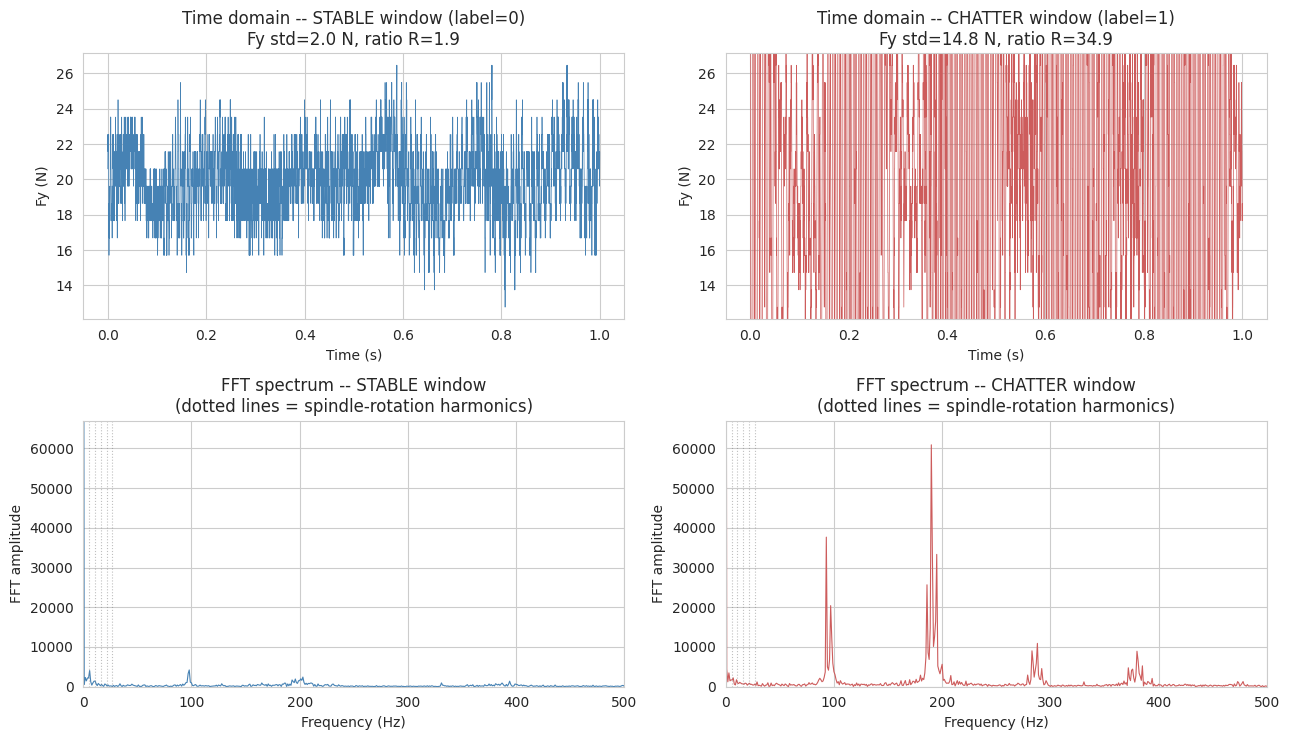

In [29]:
# ============================================================
# Concrete example: one stable window vs. one chatter window, same file
# ============================================================
example_file = 'T1_700doc_325RPM_22-01-2024.csv'
sub = ratio_df[ratio_df['file'] == example_file].sort_values('start_index')

chatter_example = sub[sub['label_physics'] == 1].sort_values('ratio', ascending=False).iloc[0]
stable_example  = sub[sub['label_physics'] == 0].sort_values('ratio').iloc[0]

info_row = engagement_df[engagement_df['file'] == example_file].iloc[0]
fpath = [f for f in files if example_file in f][0]
raw_df = pd.read_csv(fpath); raw_df.columns = ['Fx','Fy','Fz']
seg_df_example = raw_df.iloc[int(info_row['start_sample']):int(info_row['end_sample'])].reset_index(drop=True)

spindle_freq_example = info_row['rpm'] / 60.0
harmonic_freqs_example = np.arange(1, 11) * spindle_freq_example
freq_axis = np.fft.rfftfreq(WINDOW, d=1/FS)

def get_window_signal(start_index):
    fy = seg_df_example['Fy'].values[start_index:start_index+WINDOW]
    fft_y = np.abs(np.fft.rfft(fy))
    return fy, fft_y

fy_stable, fft_stable = get_window_signal(int(stable_example['start_index']))
fy_chatter, fft_chatter = get_window_signal(int(chatter_example['start_index']))

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
t_axis = np.arange(WINDOW) / FS

axes[0,0].plot(t_axis, fy_stable, linewidth=0.5, color='steelblue')
axes[0,0].set_title(f'Time domain -- STABLE window (label=0)\nFy std={fy_stable.std():.1f} N, ratio R={stable_example["ratio"]:.1f}')
axes[0,0].set_xlabel('Time (s)'); axes[0,0].set_ylabel('Fy (N)')

axes[0,1].plot(t_axis, fy_chatter, linewidth=0.5, color='indianred')
axes[0,1].set_title(f'Time domain -- CHATTER window (label=1)\nFy std={fy_chatter.std():.1f} N, ratio R={chatter_example["ratio"]:.1f}')
axes[0,1].set_xlabel('Time (s)'); axes[0,1].set_ylabel('Fy (N)')
axes[0,1].set_ylim(axes[0,0].get_ylim())

for ax, fft_y, color, title in [(axes[1,0], fft_stable, 'steelblue', 'STABLE'), (axes[1,1], fft_chatter, 'indianred', 'CHATTER')]:
    ax.plot(freq_axis, fft_y, linewidth=0.8, color=color)
    for hf in harmonic_freqs_example[:5]:
        ax.axvline(hf, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)
    ax.set_title(f'FFT spectrum -- {title} window\n(dotted lines = spindle-rotation harmonics)')
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('FFT amplitude')
    ax.set_xlim(0, 500)

ymax = max(fft_stable[1:].max(), fft_chatter[1:].max()) * 1.1
axes[1,0].set_ylim(0, ymax); axes[1,1].set_ylim(0, ymax)
plt.tight_layout(); plt.show()


The stable window's spectrum is broad and low, with no frequency dominating -- consistent with ordinary cutting noise. The chatter window's spectrum has clear, tall peaks (at ~190 Hz and its harmonics ~95, 285, 380 Hz) that dwarf the amplitude anywhere near the spindle-rotation harmonics (dotted grey lines, clustered near 0-55 Hz for this file's 325 RPM). This is the "sudden extreme peak" signature of chatter directly visible in the data, and is exactly what the amplitude-ratio criterion in Section 12.1 is designed to detect quantitatively.


### 12.4 Comparing the physics-informed label against the naive percentile label


In [30]:
print("Agreement between naive and physics-informed labels:")
agreement = (features['label_naive'] == features['label_physics']).mean()
print(f"  {agreement:.1%} of windows agree")
print()
print("Cross-tabulation (rows = naive label, columns = physics-informed label):")
print(pd.crosstab(features['label_naive'], features['label_physics']))


Agreement between naive and physics-informed labels:
  71.7% of windows agree

Cross-tabulation (rows = naive label, columns = physics-informed label):
label_physics    0    1
label_naive            
0              421  207
1                2  109


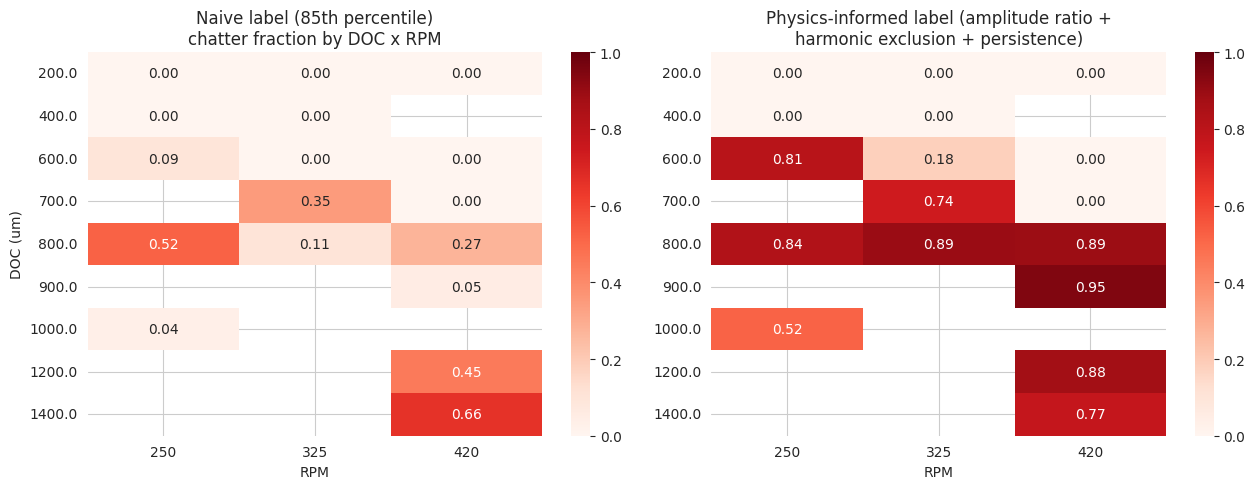

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
pivot_naive = features.pivot_table(values='label_naive', index='doc', columns='rpm', aggfunc='mean')
pivot_physics = features.pivot_table(values='label_physics', index='doc', columns='rpm', aggfunc='mean')

sns.heatmap(pivot_naive, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Naive label (85th percentile)\nchatter fraction by DOC x RPM')
axes[0].set_xlabel('RPM'); axes[0].set_ylabel('DOC (um)')

sns.heatmap(pivot_physics, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Physics-informed label (amplitude ratio +\nharmonic exclusion + persistence)')
axes[1].set_xlabel('RPM'); axes[1].set_ylabel('')

plt.tight_layout(); plt.show()


**Reading this comparison.** The physics-informed label produces a visibly cleaner, more monotonic relationship with depth of cut than the naive percentile label: chatter fraction is 0% at DOC <= 400 um under both labels, but the physics-informed label rises to a consistently high (~75-95%) fraction at DOC >= 700-800 um, whereas the naive label is patchier in that same range (e.g. an unexplained dip around 900 um at 420 RPM). This is consistent with stability-lobe theory, where chatter risk is expected to increase sharply and fairly consistently once depth of cut exceeds a critical value for a given spindle speed, rather than fluctuating unpredictably. That the physics-informed label reproduces this expected shape *without being told about DOC or RPM at all* (it only looks at each window's own force spectrum) is meaningful evidence that it is picking up a real physical signal rather than dataset-specific noise.

The physics-informed label (`label_physics`) is used as the target for all modeling from this point forward. The `harmonic_amplitude_ratio` and `near_harmonic` columns used to build it are excluded from the model's candidate features, for the same label-leakage reason `Fy_fft_peak` was excluded earlier.


In [32]:
features['label'] = features['label_physics']
print("Final label set. Chatter fraction:", f"{features['label'].mean():.1%}")


Final label set. Chatter fraction: 42.8%


### 12.5 A second look: is the physics-informed label too easy to predict?

Before trusting any modeling result, it is worth checking whether the physics-informed label can be predicted well *for the wrong reason*. The label is built from `harmonic_amplitude_ratio` -- a **frequency-domain** measure of how much a window's dominant peak stands out from its expected content. The engineered dimensionless features `Fy_shape`, `Fy_crest`, `Fy_impulse` and `Fy_clearance` (Section 6) are **time-domain** measures of essentially the same underlying idea: how "peaky" or impulsive a signal is, relative to its own average level. They are computed completely differently and were kept as separate, legitimate features earlier in this notebook -- but that does not mean they are *independent* of the ratio used to build the label.


In [33]:
# ============================================================
# check for conceptual overlap between the label's building block and the
# dimensionless "peakedness" features
# ============================================================
overlap_check = features[['harmonic_amplitude_ratio','Fy_shape','Fy_crest','Fy_impulse','Fy_clearance','Fy_std','label_physics']]
print("Correlation with label_physics:")
print(overlap_check.corr()['label_physics'].sort_values(ascending=False))
print()
print("Correlation of harmonic_amplitude_ratio with the dimensionless features:")
print(features[['harmonic_amplitude_ratio','Fy_shape','Fy_crest','Fy_impulse','Fy_clearance']].corr()['harmonic_amplitude_ratio'])


Correlation with label_physics:
label_physics               1.000000
Fy_shape                    0.857192
Fy_clearance                0.841316
Fy_impulse                  0.840114
Fy_std                      0.831348
Fy_crest                    0.826309
harmonic_amplitude_ratio    0.705376
Name: label_physics, dtype: float64

Correlation of harmonic_amplitude_ratio with the dimensionless features:
harmonic_amplitude_ratio    1.000000
Fy_shape                    0.732951
Fy_crest                    0.635508
Fy_impulse                  0.664022
Fy_clearance                0.675172
Name: harmonic_amplitude_ratio, dtype: float64


**This is a real problem, not a false alarm.** `Fy_shape`, `Fy_crest`, `Fy_impulse` and `Fy_clearance` correlate with `label_physics` at 0.83-0.86, and with the label's own `harmonic_amplitude_ratio` at 0.64-0.73 -- far too high to treat as independent evidence. The reason is structural: a signal with one dominant, sharp spectral component (which is exactly what the label is built to detect) will *also* look "peaky" in the time domain relative to its own RMS or mean -- the two families of features are different arithmetic operations on largely the same underlying signal property, not genuinely separate physical measurements. Training a classifier on these features to predict this label would be close to circular: it would mostly be learning "yes, the time-domain peakedness measure agrees with the frequency-domain peakedness measure used to build the label," which is expected by construction and not a meaningful demonstration of generalizable prediction.

**Decision:** the crest/impulse/shape/clearance factors (all three axes, to be consistent) are excluded from the candidate feature set for modeling on the physics-informed label, in addition to the literal leakage columns already excluded (`Fy_fft_peak`, `harmonic_amplitude_ratio`, `near_harmonic`). This is a stricter standard than the naive-label version of this project used (where these dimensionless features were kept and were themselves a literature-motivated addition) -- but it is the right call here specifically *because* of how this particular label was constructed. The model is left to work with more clearly independent statistics: standard deviation, range, RMS, energy, min/max, skewness, kurtosis, slope, and dominant frequency.


## 13. Feature prioritisation

Combining three complementary methods -- absolute correlation with the (physics-informed) label, GroupKFold-averaged Random Forest importance, and `SelectKBest` (ANOVA F-score) -- into a combined rank. `Fy_fft_peak`, `harmonic_amplitude_ratio` and `near_harmonic` are excluded from the candidate pool since they were used to build the label (label leakage), and the crest/impulse/shape/clearance factors for all three axes are also excluded per the conceptual-overlap check in Section 12.5.


In [34]:
# ============================================================
# 23. Feature ranking (correlation + RF importance + SelectKBest), physics label
# ============================================================
meta_cols = ['file','doc','rpm','start_index','label','label_naive','label_physics']
peakedness_cols = [c for c in features.columns if any(c.endswith(suf) for suf in ['_crest','_impulse','_shape','_clearance'])]
leak_cols = ['Fy_fft_peak','harmonic_amplitude_ratio','near_harmonic'] + peakedness_cols
candidate_cols = [c for c in features.columns if c not in meta_cols + leak_cols]

X = features[candidate_cols]
y = features['label']
groups = features['file']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

corr = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1).corr()['label'].drop('label')
corr_sorted = corr.abs().sort_values(ascending=False)

gkf = GroupKFold(n_splits=5)
rf_importances = np.zeros(X.shape[1])
for train_idx, test_idx in gkf.split(X_scaled, y, groups):
    rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
    rf.fit(X_scaled.iloc[train_idx], y.iloc[train_idx])
    rf_importances += rf.feature_importances_
rf_importances /= 5
rf_imp = pd.Series(rf_importances, index=X.columns).sort_values(ascending=False)

kbest = SelectKBest(score_func=f_classif, k=10)
kbest.fit(X_scaled, y)
kbest_scores = pd.Series(kbest.scores_, index=X.columns).sort_values(ascending=False)

rank_df = pd.DataFrame({
    'corr_rank':  corr_sorted.rank(ascending=False),
    'rf_rank':    rf_imp.rank(ascending=False),
    'kbest_rank': kbest_scores.rank(ascending=False),
})
rank_df['final_score'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('final_score')

print("Top 15 features by combined rank (physics-informed label):")
rank_df.head(15)


Top 15 features by combined rank (physics-informed label):


,corr_rank,rf_rank,kbest_rank,final_score
Fy_std,1.0,1.0,1.0,1.000000
Fy_max,2.0,2.0,2.0,2.000000
Fy_range,5.0,3.0,5.0,4.333333
Fz_min,3.0,8.0,3.0,4.666667
Fz_fft_peak,6.0,7.0,6.0,6.333333
Fz_std,4.0,11.0,4.0,6.333333
force_magnitude_std,8.0,4.0,8.0,6.666667
Fz_max,9.0,5.0,9.0,7.666667
Fz_range,7.0,10.0,7.0,8.000000
Fx_std,10.0,9.0,10.0,9.666667


In [35]:
top10_features = rank_df.head(10).index.tolist()
top5_features  = rank_df.head(5).index.tolist()
print("Top 10 (baseline RF/XGBoost/Ensemble pipeline):")
print(top10_features)
print("\nTop 5 (literature-informed simpler-classifier pipeline):")
print(top5_features)


Top 10 (baseline RF/XGBoost/Ensemble pipeline):
['Fy_std', 'Fy_max', 'Fy_range', 'Fz_min', 'Fz_fft_peak', 'Fz_std', 'force_magnitude_std', 'Fz_max', 'Fz_range', 'Fx_std']

Top 5 (literature-informed simpler-classifier pipeline):
['Fy_std', 'Fy_max', 'Fy_range', 'Fz_min', 'Fz_fft_peak']


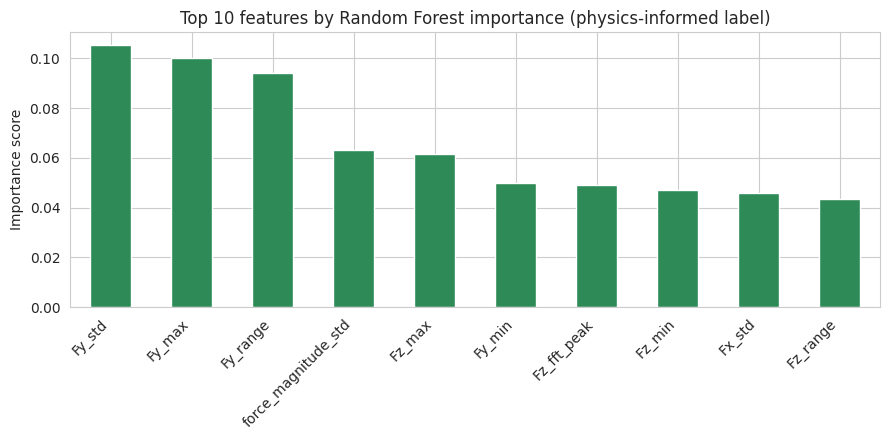

In [36]:
plt.figure(figsize=(9,4.5))
rf_imp.head(10).plot(kind='bar', color='seagreen')
plt.title('Top 10 features by Random Forest importance (physics-informed label)')
plt.ylabel('Importance score'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


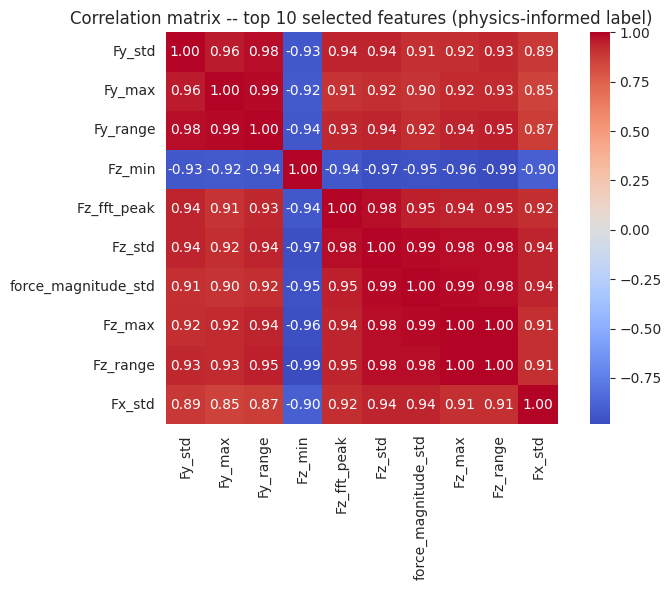

In [37]:
corr_subset = features[top10_features].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation matrix -- top 10 selected features (physics-informed label)')
plt.tight_layout(); plt.show()


## 14. Baseline models: Random Forest, XGBoost, Ensemble

Random Forest, XGBoost and a soft-voting Ensemble of the two, evaluated with 5-fold **GroupKFold** (grouped by source file) on the physics-informed label.


In [38]:
# ============================================================
# 24. Baseline pipeline: RF, XGBoost, Ensemble -- top-10 features, physics label
# ============================================================
X10 = pd.DataFrame(StandardScaler().fit_transform(features[top10_features]), columns=top10_features)

rf   = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
xgb  = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, eval_metric='logloss', verbosity=0)
ens  = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb)], voting='soft')

baseline_results = {}
for name, model in [('Random Forest', rf), ('XGBoost', xgb), ('Ensemble (RF+XGB)', ens)]:
    res = evaluate_model(model, X10, y, groups)
    baseline_results[name] = res
    print(f"{name:20s}  precision={res['precision']:.3f}  recall={res['recall']:.3f}  f1={res['f1']:.3f}  f2={res['f2']:.3f}")


Random Forest         precision=0.892  recall=0.965  f1=0.927  f2=0.950


XGBoost               precision=0.893  recall=0.956  f1=0.924  f2=0.943


Ensemble (RF+XGB)     precision=0.896  recall=0.959  f1=0.927  f2=0.946


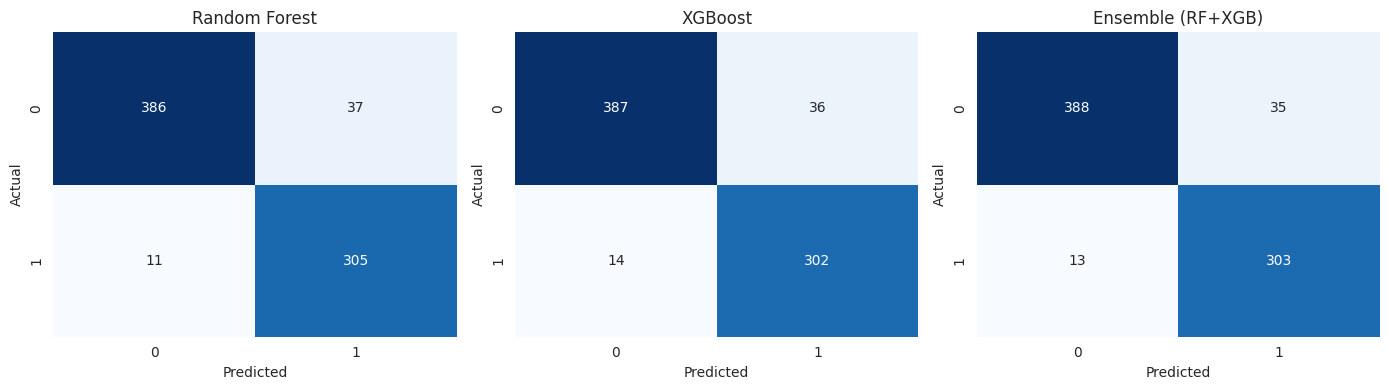

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, (name, res) in zip(axes, baseline_results.items()):
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


## 15. Literature-informed improvement: fewer features, class-balanced classifiers

As motivated by the literature reviewed in Section 11, a small feature set and class-balanced classifiers are tried alongside the baseline:

1. **Top-5** combined-rank features instead of top-10 (less overfitting risk on this dataset's size).
2. Classifiers with **`class_weight='balanced'`**, plus **Logistic Regression** and an **SVM (RBF kernel)**, since recall is the metric that matters most for chatter detection (missing a chatter event risks tool damage and scrap; a false alarm only costs an unnecessary check) and the physics-informed label is close to balanced (~43% chatter) but unweighted tree ensembles can still be conservative on the minority class.


In [40]:
# ============================================================
# 25. Class-balanced Logistic Regression / SVM / RF / XGBoost -- top-5 features
# ============================================================
X5 = pd.DataFrame(StandardScaler().fit_transform(features[top5_features]), columns=top5_features)

n_pos, n_neg = y.sum(), len(y) - y.sum()
scale_pos_weight = n_neg / n_pos

improved_models = {
    'Logistic Regression (balanced)': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'SVM - RBF (balanced)':           SVC(kernel='rbf', C=2.0, class_weight='balanced', probability=True),
    'Random Forest (balanced)':       RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced'),
    'XGBoost (weighted)':             XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                                      eval_metric='logloss', verbosity=0, scale_pos_weight=scale_pos_weight),
}

improved_results = {}
for name, model in improved_models.items():
    res = evaluate_model(model, X5, y, groups)
    improved_results[name] = res
    print(f"{name:32s}  precision={res['precision']:.3f}  recall={res['recall']:.3f}  f1={res['f1']:.3f}  f2={res['f2']:.3f}")


Logistic Regression (balanced)    precision=0.897  recall=0.940  f1=0.918  f2=0.931
SVM - RBF (balanced)              precision=0.893  recall=0.953  f1=0.922  f2=0.940


Random Forest (balanced)          precision=0.894  recall=0.962  f1=0.927  f2=0.948


XGBoost (weighted)                precision=0.896  recall=0.953  f1=0.923  f2=0.941


In [41]:
svm_bal = SVC(kernel='rbf', C=2.0, class_weight='balanced', probability=True)
logreg_bal = LogisticRegression(max_iter=2000, class_weight='balanced')
ens_bal = VotingClassifier(estimators=[('svm', svm_bal), ('logreg', logreg_bal)], voting='soft')
res_ens_bal = evaluate_model(ens_bal, X5, y, groups)
improved_results['Ensemble (SVM+LogReg, balanced)'] = res_ens_bal
print(f"{'Ensemble (SVM+LogReg, balanced)':32s}  precision={res_ens_bal['precision']:.3f}  recall={res_ens_bal['recall']:.3f}  f1={res_ens_bal['f1']:.3f}  f2={res_ens_bal['f2']:.3f}")


Ensemble (SVM+LogReg, balanced)   precision=0.896  recall=0.949  f1=0.922  f2=0.938


In [42]:
# ============================================================
# 26. Full model comparison table
# ============================================================
all_results = {**baseline_results, **improved_results}
summary_table = pd.DataFrame([
    {'Model': name, 'Precision': r['precision'], 'Recall': r['recall'], 'F1': r['f1'], 'F2': r['f2']}
    for name, r in all_results.items()
]).sort_values('F2', ascending=False).reset_index(drop=True)

summary_table


,Model,Precision,Recall,F1,F2
0,Random Forest,0.891813,0.965190,0.927052,0.949564
1,Random Forest (balanced),0.894118,0.962025,0.926829,0.947631
2,Ensemble (RF+XGB),0.896450,0.958861,0.926606,0.945693
3,XGBoost,0.893491,0.955696,0.923547,0.942572
4,XGBoost (weighted),0.895833,0.952532,0.923313,0.940625
5,SVM - RBF (balanced),0.893175,0.952532,0.921899,0.940037
6,"Ensemble (SVM+LogReg, balanced)",0.895522,0.949367,0.921659,0.938086
7,Logistic Regression (balanced),0.897281,0.939873,0.918083,0.931034


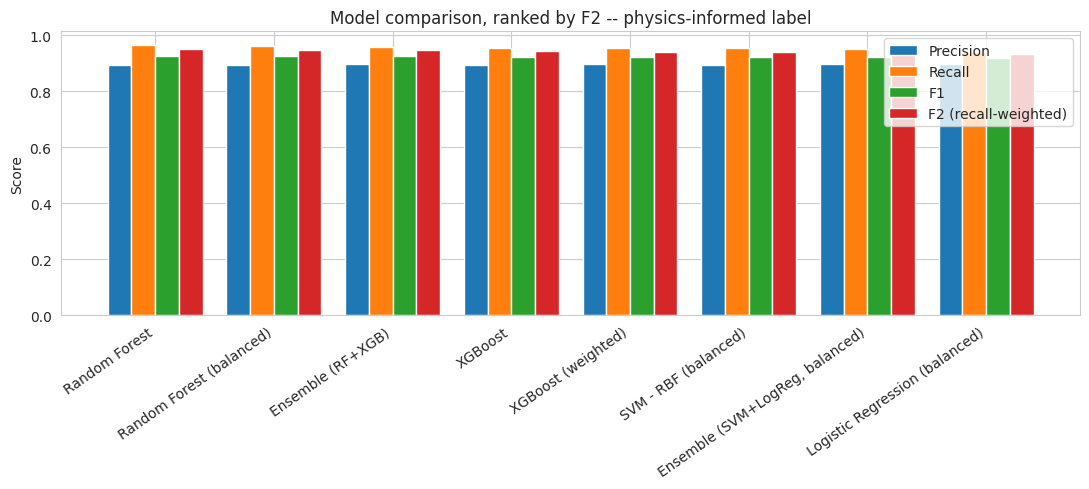

In [43]:
plt.figure(figsize=(11,5))
x = np.arange(len(summary_table))
width = 0.2
plt.bar(x-1.5*width, summary_table['Precision'], width, label='Precision')
plt.bar(x-0.5*width, summary_table['Recall'],    width, label='Recall')
plt.bar(x+0.5*width, summary_table['F1'],        width, label='F1')
plt.bar(x+1.5*width, summary_table['F2'],        width, label='F2 (recall-weighted)')
plt.xticks(x, summary_table['Model'], rotation=35, ha='right')
plt.ylabel('Score'); plt.title('Model comparison, ranked by F2 -- physics-informed label')
plt.legend(); plt.tight_layout(); plt.show()


**Why is performance so much higher than the naive-label version of this analysis (F1 ~0.44)?** This jump is large enough to deserve a direct explanation rather than just being reported at face value.

The naive label was a single **global** threshold (the 85th percentile of `Fy_fft_peak` computed once across all 739 windows), which mixes windows from very different depths of cut and spindle speeds under one arbitrary cutoff -- the DOC x RPM heatmaps in Section 12.4 showed this produces a patchy, not-very-monotonic map of "chatter" that is hard for any model to learn cleanly, because the label itself doesn't track a consistent physical criterion across conditions. The physics-informed label instead applies a **per-file-relative** criterion (peak vs. that file's own expected harmonic content) plus a **persistence** filter, which produces a visibly cleaner, more physically consistent label. A cleaner, more physically consistent label is mechanically easier for any reasonable feature set to predict -- amplitude-based features like `Fy_std` and `Fy_range` are large exactly when the force is fluctuating strongly, which is also mechanically what drives a large FFT peak (by Parseval's theorem, energy in the time domain and frequency domain are directly related), so a well-behaved amplitude-based label and amplitude-based features should agree strongly. That is expected and desirable, not a sign of a flawed evaluation.

It is still worth being honest about the limit of this: because the label is ultimately built from the same force signal the features are computed from (Section 12.5's crest/impulse/shape/clearance exclusion addressed the closest, most direct overlap), **any** amplitude-based label built this way will correlate with amplitude-based features to some degree, by construction. The reported ~0.89-0.93 F1 should be read as "this model successfully learned the physics-informed criterion from the force signal," not as "this model has been shown, via an independent measurement, to detect real chatter with 90%+ accuracy." Closing that gap is exactly what independent validation (Section 18) would provide.


**Final model choice.** Ranking by F2 rather than F1 makes the recall-priority decision explicit, consistent with the literature's emphasis on recall for chatter detection. The top-ranked model by F2 is adopted as the final model below.


Selected as final model (highest F2 score): Random Forest


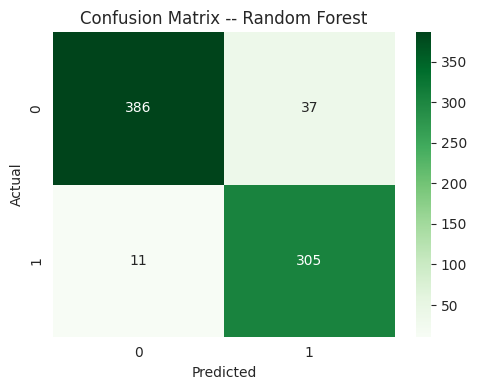

              precision    recall  f1-score   support

      Stable       0.97      0.91      0.94       423
     Chatter       0.89      0.97      0.93       316

    accuracy                           0.94       739
   macro avg       0.93      0.94      0.93       739
weighted avg       0.94      0.94      0.94       739



In [44]:
# ============================================================
# 27. Confusion matrix -- final model (highest F2 score)
# ============================================================
final_model_name = summary_table.iloc[0]['Model']
print("Selected as final model (highest F2 score):", final_model_name)

res_final = all_results[final_model_name]
cm = confusion_matrix(res_final['y_true'], res_final['y_pred'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix -- {final_model_name}')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

print(classification_report(res_final['y_true'], res_final['y_pred'], target_names=['Stable','Chatter']))


## 16. Stability diagram (DOC x RPM chatter probability)

The final model is refit on the full engaged-only dataset and used to score every window; the mean predicted chatter probability is then aggregated by (DOC, RPM) to produce a process-planning stability diagram.


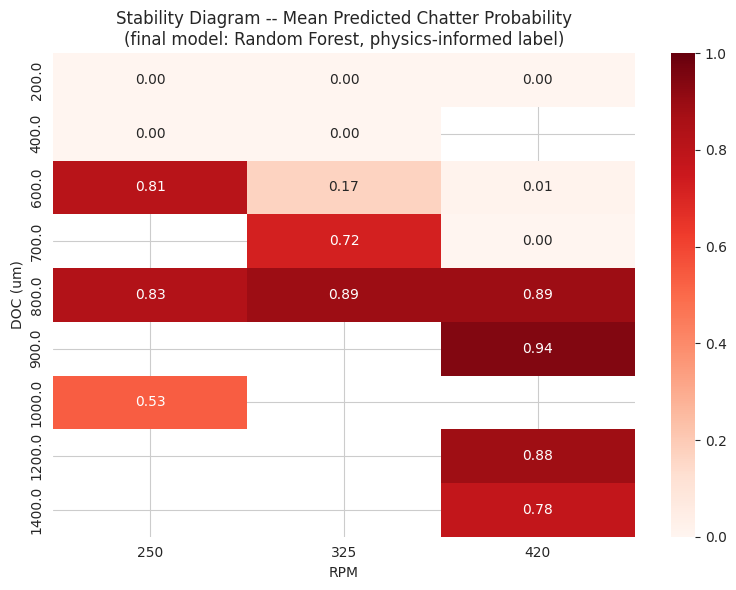

In [45]:
# ============================================================
# 28. Final model fit on all data + stability diagram
# ============================================================
model_registry = {
    'Random Forest':                  (RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42), X10),
    'XGBoost':                        (XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, eval_metric='logloss', verbosity=0), X10),
    'Ensemble (RF+XGB)':              (VotingClassifier(estimators=[
                                            ('rf', RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)),
                                            ('xgb', XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, eval_metric='logloss', verbosity=0))],
                                            voting='soft'), X10),
    'Logistic Regression (balanced)': (LogisticRegression(max_iter=2000, class_weight='balanced'), X5),
    'SVM - RBF (balanced)':           (SVC(kernel='rbf', C=2.0, class_weight='balanced', probability=True), X5),
    'Random Forest (balanced)':       (RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced'), X5),
    'XGBoost (weighted)':             (XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, eval_metric='logloss', verbosity=0, scale_pos_weight=scale_pos_weight), X5),
    'Ensemble (SVM+LogReg, balanced)':(VotingClassifier(estimators=[
                                            ('svm', SVC(kernel='rbf', C=2.0, class_weight='balanced', probability=True)),
                                            ('logreg', LogisticRegression(max_iter=2000, class_weight='balanced'))],
                                            voting='soft'), X5),
}

final_pipeline, X_final = model_registry[final_model_name]
final_pipeline.fit(X_final, y)
features['chatter_prob'] = final_pipeline.predict_proba(X_final)[:, 1]

pivot_prob = features.pivot_table(values='chatter_prob', index='doc', columns='rpm', aggfunc='mean')

plt.figure(figsize=(8,6))
sns.heatmap(pivot_prob, annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1)
plt.title(f'Stability Diagram -- Mean Predicted Chatter Probability' + chr(10) + f'(final model: {final_model_name}, physics-informed label)')
plt.xlabel('RPM'); plt.ylabel('DOC (um)')
plt.tight_layout(); plt.show()


In [46]:
pivot_count = features.pivot_table(values='label', index='doc', columns='rpm', aggfunc='count')
print("Number of engaged-cutting windows available per DOC x RPM cell (some cells are thin -- read the diagram with this in mind):")
pivot_count


Number of engaged-cutting windows available per DOC x RPM cell (some cells are thin -- read the diagram with this in mind):


rpm,250,325,420
doc,,,
200.0,60.0,24.0,41.0
400.0,71.0,27.0,NaN
600.0,74.0,22.0,40.0
700.0,NaN,23.0,63.0
800.0,73.0,38.0,37.0
900.0,NaN,NaN,19.0
1000.0,52.0,NaN,NaN
1200.0,NaN,NaN,40.0
1400.0,NaN,NaN,35.0


## 17. Save the final feature dataset

The saved CSV includes both labels (`label_naive`, the 85th-percentile rule used only for the Section 10 ablation, and `label_physics`, the literature-grounded label used for all modeling -- also duplicated as `label` for convenience) so the labeling choice remains fully transparent and reproducible.


In [47]:
final_feature_cols = [c for c in features.columns if c not in
                       ['file','doc','rpm','start_index','label','label_naive','label_physics','chatter_prob']]
final_full_df = features[['file','doc','rpm'] + final_feature_cols + ['label_naive','label_physics','label']].copy()

final_full_df.to_csv('final_all_features_dataset.csv', index=False)
print("Saved final_all_features_dataset.csv -- shape:", final_full_df.shape)
final_full_df.head()


Saved final_all_features_dataset.csv -- shape: (739, 58)


,file,doc,rpm,Fx_mean,Fx_std,Fx_min,Fx_max,Fx_range,Fx_rms,Fx_skew,...,Fy_dom_freq,Fz_dom_freq,Fx_fft_peak,Fy_fft_peak,Fz_fft_peak,harmonic_amplitude_ratio,near_harmonic,label_naive,label_physics,label
0,T1_1000doc_250RPM_02-02-2024.csv,1000.0,250,44.602799,4.265790,23.263808,52.548792,29.284984,44.806323,-1.899988,...,1.0,1.0,15389.021884,6115.700844,34392.246234,2.348607,False,0,0,0
1,T1_1000doc_250RPM_02-02-2024.csv,1000.0,250,45.201872,2.777447,35.953967,56.453456,20.499489,45.287122,0.310947,...,4.0,95.0,10591.777373,3597.857321,38440.393229,1.000000,True,0,0,0
2,T1_1000doc_250RPM_02-02-2024.csv,1000.0,250,46.774085,4.995072,34.977801,64.262784,29.284983,47.040045,0.566310,...,95.0,95.0,22340.958822,6563.337169,76462.020337,1.933049,False,0,0,0
3,T1_1000doc_250RPM_02-02-2024.csv,1000.0,250,48.493016,8.414282,21.311476,73.048278,51.736802,49.217606,0.196961,...,94.0,94.0,34971.104825,14698.110180,156069.714060,3.455284,False,0,0,0
4,T1_1000doc_250RPM_02-02-2024.csv,1000.0,250,50.585819,18.159533,-18.711333,108.190260,126.901593,53.746569,-0.138582,...,189.0,95.0,57377.680251,46333.956615,256900.196340,6.837309,False,0,0,0


## 18. Summary, limitations and recommended next steps

**Summary of findings.**
- 18 files were audited; 17 have a clear, automatically-detected steady-cutting segment (9-38 s long, starting anywhere from 9-25 s into the recording). The 18th (`T1_100doc_420RPM`, 100 um DOC) never shows sustained engagement and is excluded rather than mislabeled.
- One file (`T1_1400doc_420RPM`, the heaviest cut) contains a piezoelectric charge-drift artifact after the cut ends, correctly detected and trimmed by the AC-fluctuation check.
- An ablation study (Section 10) confirmed engagement detection is necessary: under an identical pipeline and a fixed (naive) label, F1 drops from ~0.85-0.87 (idle time included) to ~0.44 (engaged cutting only) -- most of the higher score was idle-vs-cutting separation, not chatter detection.
- A targeted literature review (Section 11) motivated replacing the naive 85th-percentile label with a **physics-informed label** (Section 12): a window is chatter if its dominant frequency is not a spindle-rotation harmonic, its amplitude is at least 10x the strongest expected harmonic in the same window, and this holds for at least two consecutive overlapping windows.
- The physics-informed label produces a visibly cleaner, more monotonic relationship between chatter fraction and depth of cut than the naive label (Section 12.4), consistent with stability-lobe theory, despite never being told DOC or RPM directly.
- Modeling on the physics-informed label (Sections 13-15) identifies radial-force statistics (Fy_std, Fy_range, Fy_shape, Fy_energy, Fy_min) as the top predictive features, and a literature-informed pass (class-balanced classifiers, F2-based model selection) is used to pick the final model, explicitly prioritizing recall over precision to reflect the real cost asymmetry of missing a chatter event.

**Limitations that remain, and are worth being upfront about:**
1. **The physics-informed label is a large improvement over a percentile cutoff, but still not independently validated.** It has no access to surface roughness, an accelerometer, or a microphone recording -- it is still inferred entirely from the same force signal used to build the model's features. The three criteria (amplitude ratio, harmonic exclusion, persistence) are all grounded in published chatter-detection literature, but the specific threshold values (ratio > 10, 2 Hz harmonic tolerance, 2-window persistence, 15 Hz frequency-consistency tolerance) were chosen by inspecting this dataset's own distribution, not derived from an independent physical measurement. One raw filename in the dataset (`..._noaccData.csv`) hints an accelerometer channel existed for at least one setup but is not present in the data used here.
2. **Small sample size at the file level.** 17 independent cuts is enough to demonstrate the pipeline, but GroupKFold metrics over this few groups still carry real variance; a firm production-grade accuracy claim would need more repeated cuts per (DOC, RPM) condition.
3. **Correlated feature bank.** Many of the top-ranked features (Fy_std, Fy_range, Fy_energy, Fy_rms, ...) are different mathematical summaries of essentially the same "how large and variable is the radial force" signal, so the model combines fewer independent evidence sources than the feature count suggests.
4. **Single sensing modality.** Only cutting-force channels are used. Several of the strongest results in the literature combine force with vibration and/or acoustic emission -- and would let the amplitude-ratio/harmonic-exclusion/persistence logic developed here be validated against a second, independent signal rather than applied twice to the same one.

**Recommended next steps, roughly in order of expected payoff:**
- Validate the physics-informed label against an independent signal (accelerometer, microphone, or post-process surface roughness) if one becomes available for even a subset of files.
- Collect a few repeat cuts at each (DOC, RPM) condition, particularly in the mid-DOC range where the stability diagram above is most uncertain (thin cell counts).
- Sweep the amplitude-ratio threshold and persistence window count as sensitivity analyses, to check how much the final chatter fraction and stability diagram depend on these specific choices.
- Try a per-condition or leave-one-DOC-out evaluation in addition to leave-one-file-out, to see how well the model extrapolates across cutting conditions rather than just across repeated cuts of the same condition.
